<a href="https://colab.research.google.com/github/parthibray2002/Optimizing-IPL-Auctions-using-Gen-AI-ML-/blob/main/MS_Implementation_Combined_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from google.colab import drive, files

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = '/content/drive/My Drive/Upgrad MS Datasets/Combined_Cricket_Data.csv'

# 3. Read the 4th sheet (index 3)
df_combined = pd.read_csv(file_path)

In [ ]:
df_combined

,Player,Category,Country,Role,Runs Scored,Batting Strike Rate,Batting Average,No of Sixes,No of Fours,Balls Faced,...,Fours Conceded,Dot Balls Bowled,Maidens Bowled,Age of the Player,Capped/Uncapped,Last Auction Price Sold (in Crs),5 Wicket hauls,No of Catches,No of Stumpings,No of Run Outs
0,Hardik Pandya,International,India,Fast-All Rounder,2757.0,147.00,28.34,149.0,207.0,1875.0,...,222.0,582.0,1.0,32,Capped,16.35,NaN,NaN,NaN,NaN
1,Ravindra Jadeja,International,India,Spin-All Rounder,2356.0,134.30,28.10,82.0,175.0,1754.0,...,265.0,1116.0,2.0,37,Capped,18.00,NaN,NaN,NaN,NaN
2,Shivam Dube,International,India,Fast-All Rounder,903.0,149.80,30.48,57.0,56.0,603.0,...,53.0,159.0,0.0,32,Capped,12.00,NaN,NaN,NaN,NaN
3,Nitish Kumar Reddy,International,India,Fast-All Rounder,485.0,132.90,28.52,25.0,31.0,365.0,...,16.0,39.0,0.0,22,Capped,6.00,NaN,NaN,NaN,NaN
4,Axar Patel,International,India,Spin-All Rounder,1910.0,134.20,22.02,94.0,129.0,1423.0,...,259.0,1132.0,2.0,32,Capped,16.50,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1873,Player_346,International,Australia,Batsman,866.0,197.16,34.68,39.0,94.0,344.0,...,NaN,NaN,NaN,26,Capped,10.15,NaN,NaN,NaN,NaN
1874,Player_347,International,India,Batsman,1880.0,132.45,34.96,75.0,199.0,988.0,...,NaN,NaN,NaN,34,Uncapped,5.49,NaN,NaN,NaN,NaN
1875,Player_348,International,West Indies,Batsman,1151.0,146.66,24.67,55.0,71.0,798.0,...,NaN,NaN,NaN,34,Capped,4.79,NaN,NaN,NaN,NaN
1876,Player_349,International,England,Batsman,7088.0,147.57,41.70,124.0,791.0,5123.0,...,NaN,NaN,NaN,31,Capped,1.69,NaN,NaN,NaN,NaN


In [ ]:
df_combined['Last Auction Price Sold (in Crs)'].isnull().sum()

np.int64(0)

In [ ]:
import numpy as np

# Define the column for auction price
auction_price_col = 'Last Auction Price Sold (in Crs)'

# Ensure the column exists in df_scrambled
if auction_price_col in df_combined.columns:
    # Define the new thresholds based on user request
    low_threshold_value = 0.5  # 1 Crore
    high_threshold_value = 7 # 7 Crores

    # Define bins and labels based on the new thresholds
    # Order: (-inf, 1] -> Low, (1, 7] -> Mid, (7, inf) -> High
    bins = [-np.inf, low_threshold_value, high_threshold_value, np.inf]
    labels = ['Low Value', 'Mid Value', 'High Value']

    # Create the new categorical column 'Player_Value_Category'
    df_combined['Player_Value_Category'] = pd.cut(df_combined[auction_price_col], bins=bins, labels=labels, include_lowest=True)

    print(f"Player Value Categories created based on '{auction_price_col}' with new thresholds:")
    display(df_combined['Player_Value_Category'].value_counts())

    # Display the first few rows with the new column
    print("\nFirst 5 rows of df_scrambled with 'Player_Value_Category':")
    display(df_combined[[auction_price_col, 'Player_Value_Category']].head())
else:
    print(f"Error: '{auction_price_col}' column not found in df_scrambled. Please ensure the column name is correct.")

Player Value Categories created based on 'Last Auction Price Sold (in Crs)' with new thresholds:


,count
Player_Value_Category,
Mid Value,1095
Low Value,488
High Value,295



First 5 rows of df_scrambled with 'Player_Value_Category':


,Last Auction Price Sold (in Crs),Player_Value_Category
0,16.35,High Value
1,18.00,High Value
2,12.00,High Value
3,6.00,Mid Value
4,16.50,High Value


In [ ]:
df_combined ['Player_Value_Category']

,Player_Value_Category
0,High Value
1,High Value
2,High Value
3,Mid Value
4,High Value
...,...
1873,High Value
1874,Mid Value
1875,Mid Value
1876,Mid Value


### Preprocessing and Scrambling Data

To 'scramble' the data for potential machine learning tasks, we will perform the following steps on the `df_combined` DataFrame, which now includes the `Player_Value_Category`:
1.  **Anonymize Player Names**: Replace player names with generic IDs.
2.  **One-Hot Encode Categorical Features**: Convert categorical columns into a numerical format suitable for models.
3.  **Scale Numerical Features**: Normalize numerical features to a standard range.
4.  **Shuffle the dataset**: Randomly reorder the rows of the DataFrame.

In [ ]:
# 1. Anonymize Player Names
df_processed = df_combined.copy()
df_processed['Player_ID'] = range(1, len(df_processed) + 1)
df_processed = df_processed.drop('Player', axis=1)

# Define categorical and numerical features for preprocessing
categorical_features = ['Category', 'Country', 'Role', 'Capped/Uncapped', 'Player_Value_Category']

# Dynamically get numerical features, excluding Player_ID which is an identifier
numerical_features = df_processed.select_dtypes(include=np.number).columns.tolist()
if 'Player_ID' in numerical_features:
    numerical_features.remove('Player_ID')

# 2. One-Hot Encode Categorical Features and 3. Scale Numerical Features
# Using ColumnTransformer for robust preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns (like Player_ID) as they are
)

df_transformed = preprocessor.fit_transform(df_processed)

# Get feature names after one-hot encoding
categorical_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Get original columns that were not transformed (e.g., Player_ID which is handled by remainder)
original_cols_not_transformed = [col for col in df_processed.columns if col not in numerical_features + categorical_features]

# Create the final column names list in the correct order
final_column_names = numerical_features + list(categorical_feature_names) + original_cols_not_transformed

# Create a DataFrame from the transformed data using the correct column names
df_scrambled = pd.DataFrame(df_transformed, columns=final_column_names)

# 4. Shuffle the dataset
df_scrambled = df_scrambled.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nFirst 5 rows of the preprocessed and scrambled (anonymized, encoded, scaled, shuffled) DataFrame:")
display(df_scrambled.head())
print("\nShape of the preprocessed and scrambled DataFrame:", df_scrambled.shape)


First 5 rows of the preprocessed and scrambled (anonymized, encoded, scaled, shuffled) DataFrame:


,Runs Scored,Batting Strike Rate,Batting Average,No of Sixes,No of Fours,Balls Faced,Total career dot balls played,No of Centuries Scored,No of Half Centuries Scored,Wickets Taken,...,Role_Spin All Rounder,Role_Spin Bowler,Role_Spin-All Rounder,Role_Wk-Batsman,Capped/Uncapped_Capped,Capped/Uncapped_Uncapped,Player_Value_Category_High Value,Player_Value_Category_Low Value,Player_Value_Category_Mid Value,Player_ID
0,NaN,0.066734,0.247088,0.055238,0.024263,0.048411,0.060671,0.023256,0.034335,NaN,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1112.0
1,0.023316,0.092906,0.201024,0.064127,0.017092,0.027101,0.034389,0.011628,0.023605,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1449.0
2,NaN,0.068498,0.187152,0.024762,0.011788,0.021700,0.023551,0.000000,0.017167,NaN,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1327.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.083838,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,808.0
4,0.015564,0.066587,0.215043,0.033651,0.007466,0.020508,0.023466,0.000000,0.017167,0.045808,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,271.0



Shape of the preprocessed and scrambled DataFrame: (1878, 56)


In [ ]:
# Define features (X) and target (y)
X = df_resampled.drop('Player_Value_Category', axis=1)
y = df_resampled['Player_Value_Category']

# Split into training (65%) and temporary (35%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Split temporary set into testing (25% of original) and validation (10% of original)
# Calculate the test_size relative to the temporary set (0.10/0.35) for validation
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=(0.10/0.25), random_state=42, stratify=y_temp)

print(f"\nShape of training set: {X_train.shape}")
print(f"Shape of testing set: {X_test.shape}")
print(f"Shape of validation set: {X_val.shape}")

print("\nDistribution of Player_Value_Category in training set:")
display(y_train.value_counts(normalize=False))
print("\nDistribution of Player_Value_Category in testing set:")
display(y_test.value_counts(normalize=False))
print("\nDistribution of Player_Value_Category in validation set:")
display(y_val.value_counts(normalize=False))


Shape of training set: (675, 53)
Shape of testing set: (135, 53)
Shape of validation set: (90, 53)

Distribution of Player_Value_Category in training set:


,count
Player_Value_Category,
High Value,375
Low Value,150
Mid Value,150



Distribution of Player_Value_Category in testing set:


,count
Player_Value_Category,
High Value,75
Low Value,30
Mid Value,30



Distribution of Player_Value_Category in validation set:


,count
Player_Value_Category,
High Value,50
Low Value,20
Mid Value,20


In [ ]:
# Impute NaN values in X_train, X_test, X_val with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)
X_val = X_val.fillna(0)

print("Missing values in X_train after imputation:")
display(X_train.isnull().sum().sum())

print("Missing values in X_test after imputation:")
display(X_test.isnull().sum().sum())

print("Missing values in X_val after imputation:")
display(X_val.isnull().sum().sum())

Missing values in X_train after imputation:


np.int64(0)

Missing values in X_test after imputation:


np.int64(0)

Missing values in X_val after imputation:


np.int64(0)


--- Evaluating Logistic Regression ---

Test Set Metrics for Logistic Regression:
Accuracy: 0.7333
Precision: 0.7208
Recall: 0.7333
Confusion Matrix (Test Set):


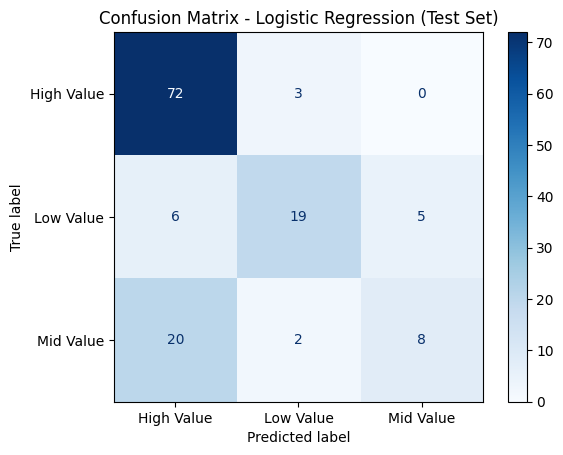


Validation Set Metrics for Logistic Regression:
Accuracy: 0.7444
Precision: 0.7599
Recall: 0.7444
Confusion Matrix (Validation Set):


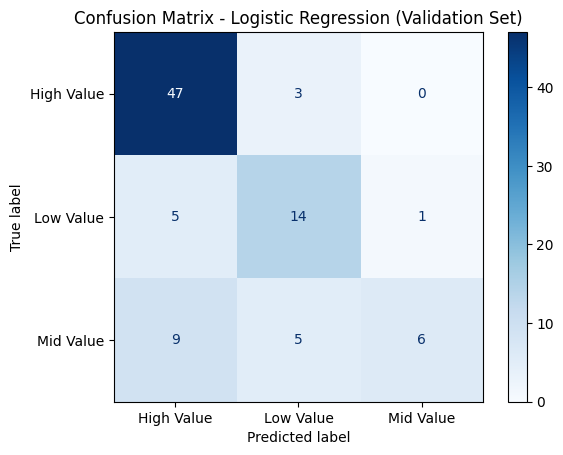

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Evaluate the model
evaluate_model(log_reg_model, X_test, y_test, X_val, y_val, "Logistic Regression")


--- Evaluating Random Forest ---

Test Set Metrics for Random Forest:
Accuracy: 0.9852
Precision: 0.9852
Recall: 0.9852
Confusion Matrix (Test Set):


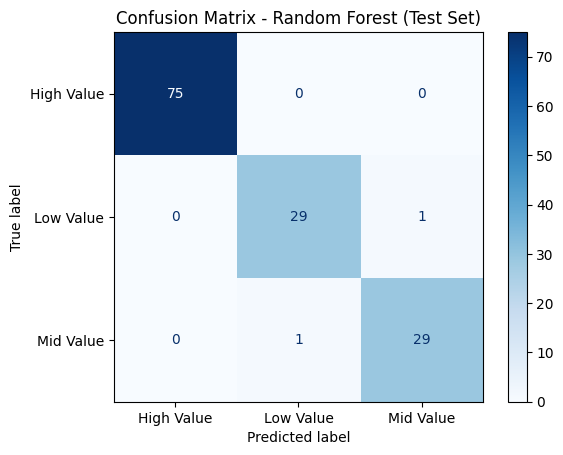


Validation Set Metrics for Random Forest:
Accuracy: 0.9667
Precision: 0.9710
Recall: 0.9667
Confusion Matrix (Validation Set):


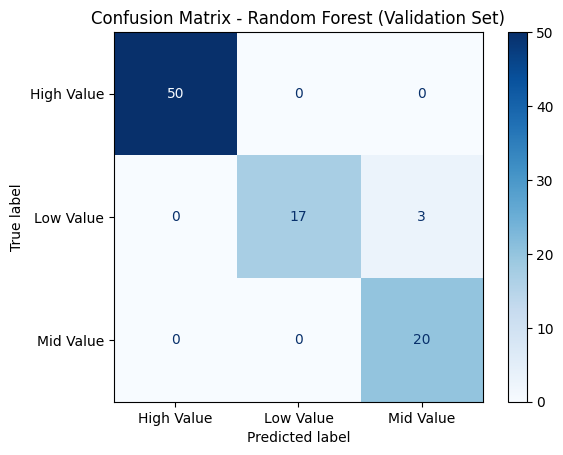

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the model
evaluate_model(rf_model, X_test, y_test, X_val, y_val, "Random Forest")


--- Evaluating Decision Tree ---

Test Set Metrics for Decision Tree:
Accuracy: 0.7778
Precision: 0.6667
Recall: 0.7778
Confusion Matrix (Test Set):


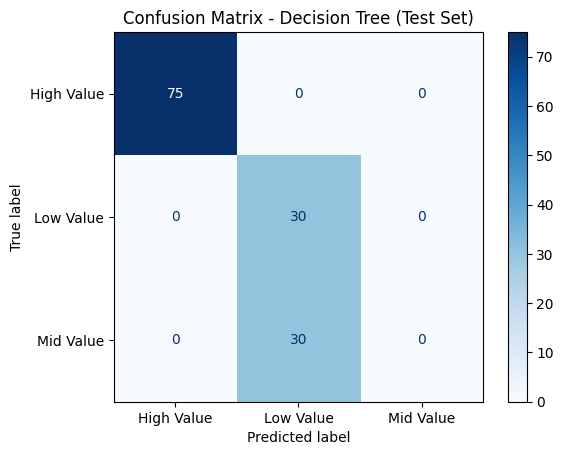


Validation Set Metrics for Decision Tree:
Accuracy: 0.7778
Precision: 0.6667
Recall: 0.7778
Confusion Matrix (Validation Set):


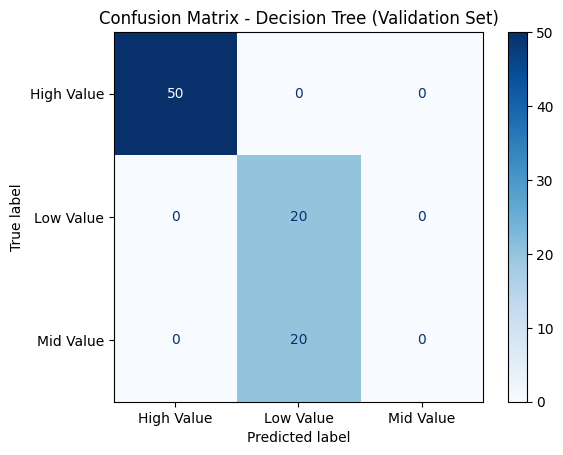

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42,max_depth=1)
dt_model.fit(X_train, y_train)

# Evaluate the model
evaluate_model(dt_model, X_test, y_test, X_val, y_val, "Decision Tree")


--- Evaluating Bagging Classifier ---

Test Set Metrics for Bagging Classifier:
Accuracy: 0.7778
Precision: 0.6667
Recall: 0.7778
Confusion Matrix (Test Set):


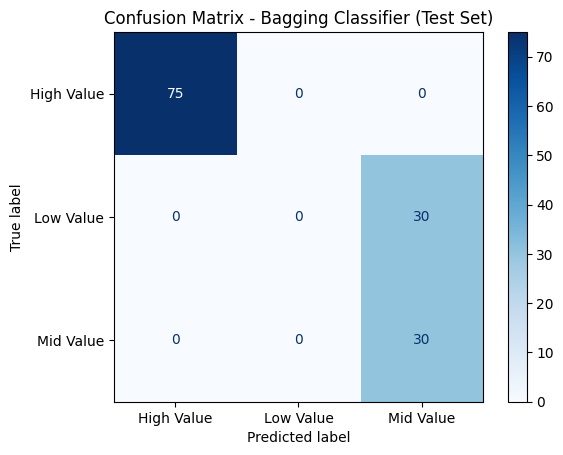


Validation Set Metrics for Bagging Classifier:
Accuracy: 0.7778
Precision: 0.6667
Recall: 0.7778
Confusion Matrix (Validation Set):


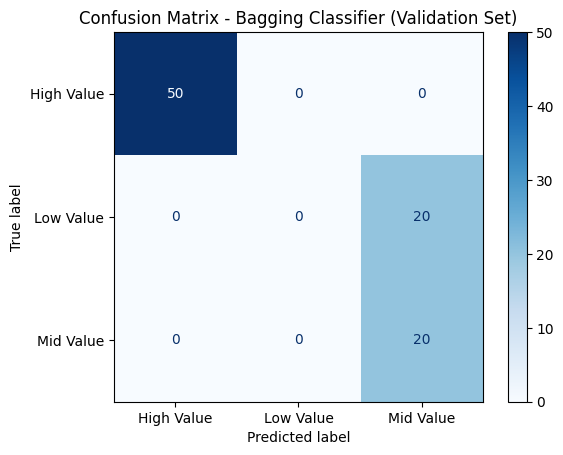

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Bagging Classifier model
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42,max_depth=1), random_state=42)
bagging_model.fit(X_train, y_train)

# Evaluate the model
evaluate_model(bagging_model, X_test, y_test, X_val, y_val, "Bagging Classifier")


--- Evaluating Gradient Boosting ---

Test Set Metrics for Gradient Boosting:
Accuracy: 0.9926
Precision: 0.9928
Recall: 0.9926
Confusion Matrix (Test Set):


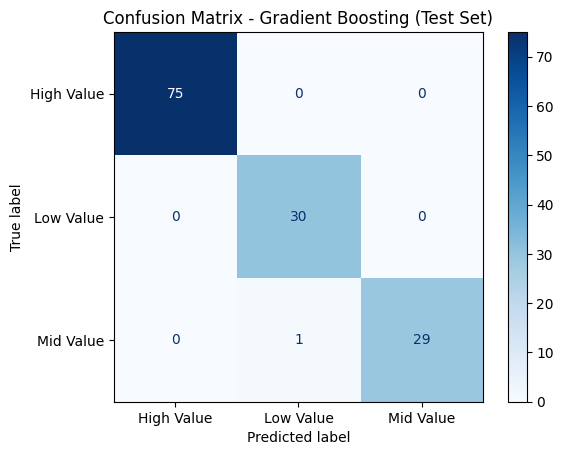


Validation Set Metrics for Gradient Boosting:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
Confusion Matrix (Validation Set):


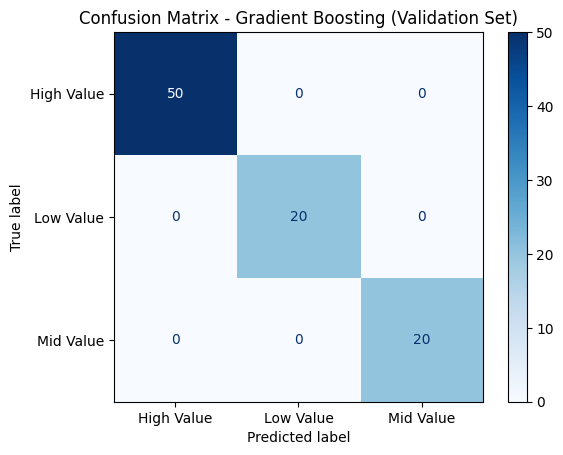

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Evaluate the model
evaluate_model(gb_model, X_test, y_test, X_val, y_val, "Gradient Boosting")


--- Hyperparameter Tuning for Logistic Regression ---
Best parameters for Logistic Regression: {'C': 100, 'solver': 'liblinear'}

--- Evaluating Tuned Logistic Regression ---

Test Set Metrics for Tuned Logistic Regression:
Accuracy: 0.8444
Precision: 0.8358
Recall: 0.8444
Confusion Matrix (Test Set):


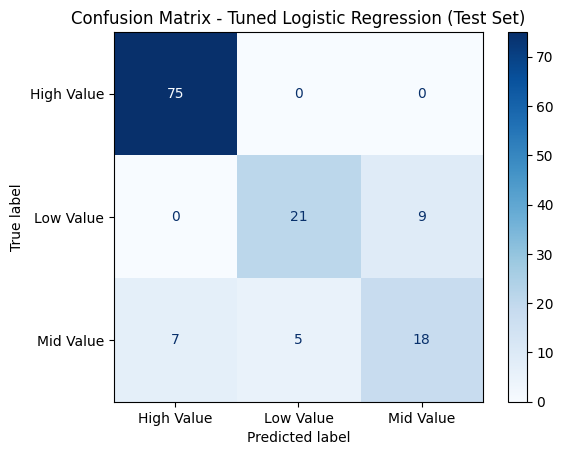


Validation Set Metrics for Tuned Logistic Regression:
Accuracy: 0.8556
Precision: 0.8498
Recall: 0.8556
Confusion Matrix (Validation Set):


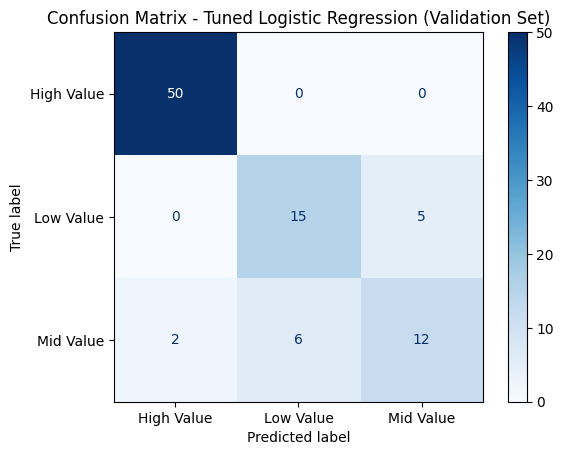


--- Hyperparameter Tuning for Random Forest ---
Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

--- Evaluating Tuned Random Forest ---

Test Set Metrics for Tuned Random Forest:
Accuracy: 0.9778
Precision: 0.9780
Recall: 0.9778
Confusion Matrix (Test Set):


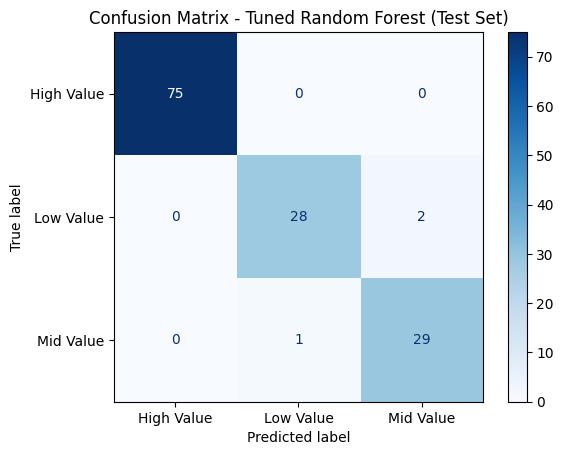


Validation Set Metrics for Tuned Random Forest:
Accuracy: 0.9667
Precision: 0.9710
Recall: 0.9667
Confusion Matrix (Validation Set):


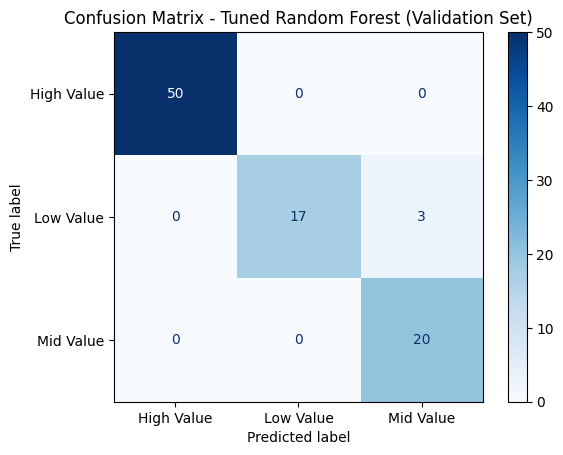


--- Hyperparameter Tuning for Decision Tree ---
Best parameters for Decision Tree: {'max_depth': None, 'min_samples_leaf': 1}

--- Evaluating Tuned Decision Tree ---

Test Set Metrics for Tuned Decision Tree:
Accuracy: 0.9926
Precision: 0.9928
Recall: 0.9926
Confusion Matrix (Test Set):


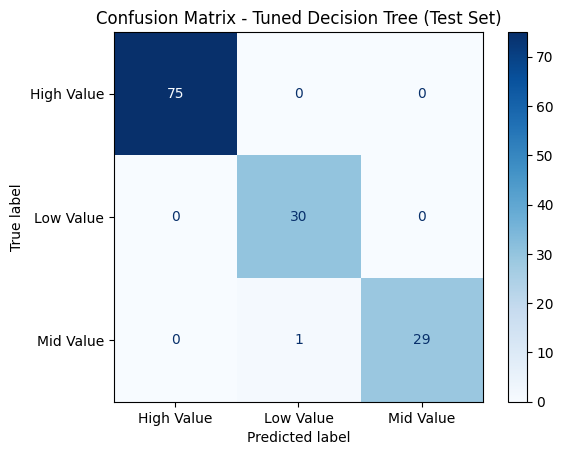


Validation Set Metrics for Tuned Decision Tree:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
Confusion Matrix (Validation Set):


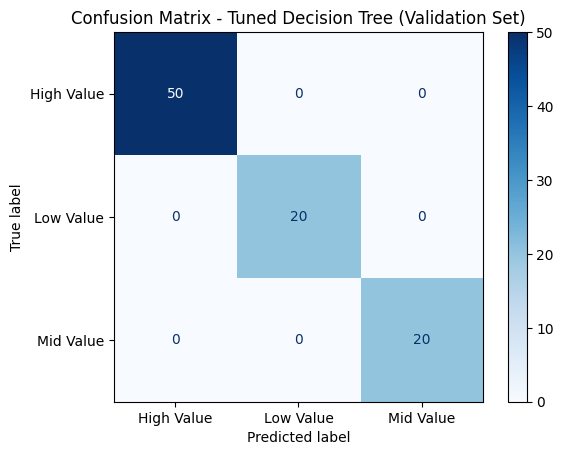


--- Hyperparameter Tuning for Bagging Classifier ---
Best parameters for Bagging Classifier: {'max_samples': 0.8, 'n_estimators': 10}

--- Evaluating Tuned Bagging Classifier ---

Test Set Metrics for Tuned Bagging Classifier:
Accuracy: 0.9926
Precision: 0.9928
Recall: 0.9926
Confusion Matrix (Test Set):


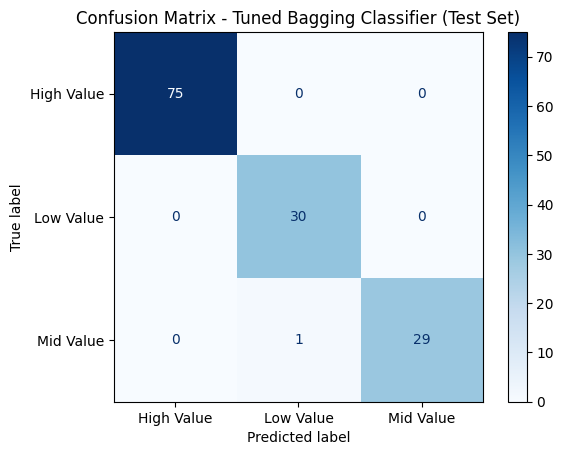


Validation Set Metrics for Tuned Bagging Classifier:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
Confusion Matrix (Validation Set):


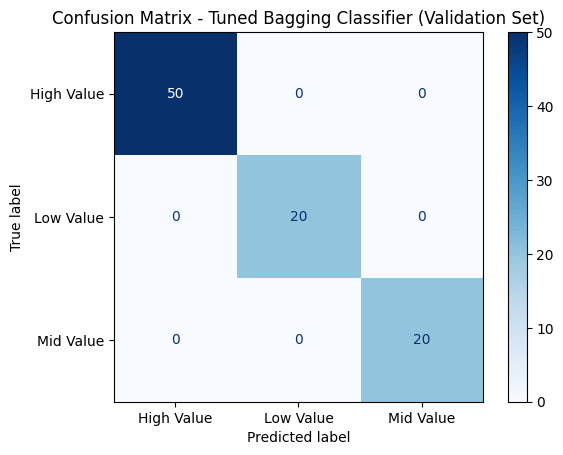


--- Hyperparameter Tuning for Gradient Boosting ---
Best parameters for Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}

--- Evaluating Tuned Gradient Boosting ---

Test Set Metrics for Tuned Gradient Boosting:
Accuracy: 0.9926
Precision: 0.9928
Recall: 0.9926
Confusion Matrix (Test Set):


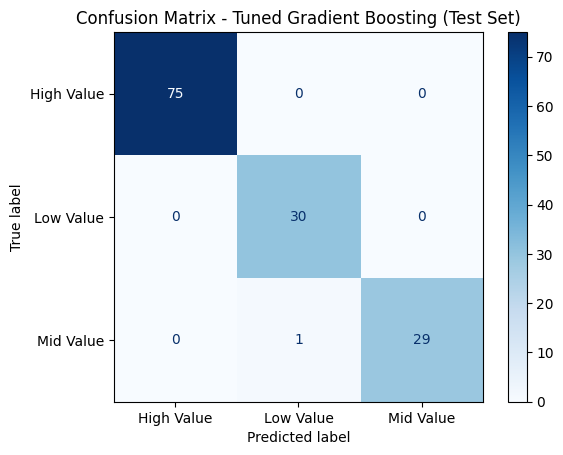


Validation Set Metrics for Tuned Gradient Boosting:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
Confusion Matrix (Validation Set):


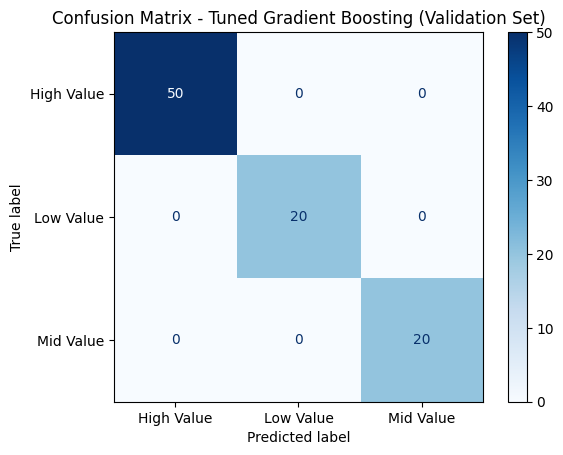

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# --- Logistic Regression Hyperparameter Tuning ---
print("\n--- Hyperparameter Tuning for Logistic Regression ---")
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_lr.fit(X_train, y_train)

best_lr_model = grid_search_lr.best_estimator_
print(f"Best parameters for Logistic Regression: {grid_search_lr.best_params_}")
evaluate_model(best_lr_model, X_test, y_test, X_val, y_val, "Tuned Logistic Regression")

# --- Random Forest Hyperparameter Tuning ---
print("\n--- Hyperparameter Tuning for Random Forest ---")
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

best_rf_model = grid_search_rf.best_estimator_
print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")
evaluate_model(best_rf_model, X_test, y_test, X_val, y_val, "Tuned Random Forest")

# --- Decision Tree Hyperparameter Tuning ---
print("\n--- Hyperparameter Tuning for Decision Tree ---")
param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10]
}
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

best_dt_model = grid_search_dt.best_estimator_
print(f"Best parameters for Decision Tree: {grid_search_dt.best_params_}")
evaluate_model(best_dt_model, X_test, y_test, X_val, y_val, "Tuned Decision Tree")

# --- Bagging Classifier Hyperparameter Tuning ---
print("\n--- Hyperparameter Tuning for Bagging Classifier ---")
param_grid_bag = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.8, 1.0]
}
grid_search_bag = GridSearchCV(BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42), param_grid_bag, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_bag.fit(X_train, y_train)

best_bag_model = grid_search_bag.best_estimator_
print(f"Best parameters for Bagging Classifier: {grid_search_bag.best_params_}")
evaluate_model(best_bag_model, X_test, y_test, X_val, y_val, "Tuned Bagging Classifier")

# --- Gradient Boosting Hyperparameter Tuning ---
print("\n--- Hyperparameter Tuning for Gradient Boosting ---")
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5]
}
grid_search_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_gb.fit(X_train, y_train)

best_gb_model = grid_search_gb.best_estimator_
print(f"Best parameters for Gradient Boosting: {grid_search_gb.best_params_}")
evaluate_model(best_gb_model, X_test, y_test, X_val, y_val, "Tuned Gradient Boosting")


--- Training CNN Model ---
CNN Model Training Complete.

Test Set Metrics for CNN Classifier:
Accuracy: 0.5556
Precision: 0.3086
Recall: 0.5556
Confusion Matrix (Test Set):


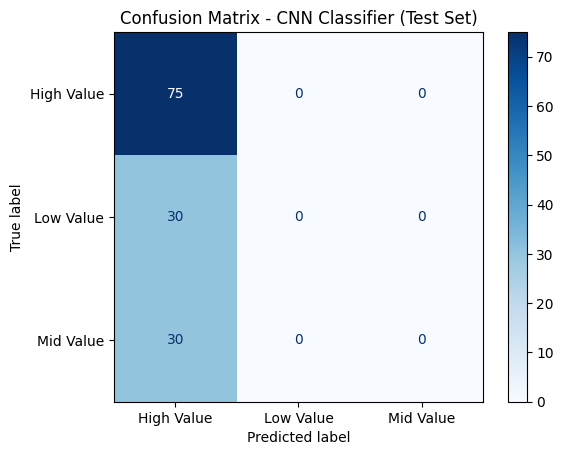


Validation Set Metrics for CNN Classifier:
Accuracy: 0.5556
Precision: 0.3086
Recall: 0.5556
Confusion Matrix (Test Set):


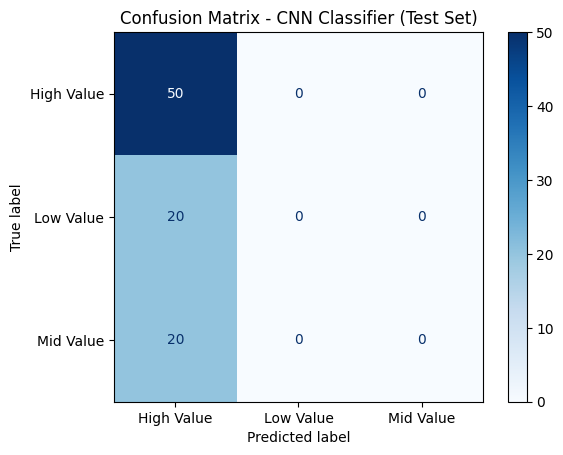

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay # Added imports

# 1. Convert data to PyTorch tensors
# First, encode the target labels (y) to numerical values if they are strings
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
y_val_encoded = label_encoder.transform(y_val)

X_train_tensor = torch.tensor(X_train.values.astype(np.float32))
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values.astype(np.float32))
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.values.astype(np.float32))
y_val_tensor = torch.tensor(y_val_encoded, dtype=torch.long)

# Create DataLoader for batch processing
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 2. Define the CNN-like model architecture
class TabularCNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(TabularCNN, self).__init__()
        # Using 1D convolution as a feature extractor, then fully connected layers
        # Reshape input to be (batch_size, channels, features) for 1D conv
        # Here, we treat each feature as a 'channel' for simplicity or could add a dummy channel dim
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

        # Calculate the output size from convolutional layers
        # Input shape: (batch_size, input_dim)
        # After unsqueeze: (batch_size, 1, input_dim)
        # After conv1: (batch_size, 16, input_dim)
        # After pool: (batch_size, 16, input_dim // 2) (assuming input_dim is even)
        # Flatten for fully connected layer
        # We need to compute this dynamically, or ensure the dimensions align

        # A simpler approach for tabular data often bypasses conv layers for direct FC layers
        # Let's use a fully connected network to represent 'CNN-like' processing for tabular data
        # as direct 1D CNN for raw tabular features can be tricky without careful reshaping

        self.fc1 = nn.Linear(input_dim, 128)  # First fully connected layer
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes) # Output layer
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # For tabular data, direct fully connected layers are more common.
        # If using 1D Conv, reshape x: x = x.unsqueeze(1) for (batch_size, 1, features)
        # Here, we'll proceed with fully connected layers as a robust approach for tabular data.
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Determine input dimension and number of classes
input_dim = X_train.shape[1]
num_classes = len(label_encoder.classes_)

cnn_model = TabularCNN(input_dim, num_classes)

# 3. Train the model
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

num_epochs = 50

print("\n--- Training CNN Model ---")
for epoch in range(num_epochs):
    cnn_model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = cnn_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    # print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")

print("CNN Model Training Complete.")

# 4. Evaluate the CNN model (custom evaluation as evaluate_model is for sklearn)
def evaluate_cnn_model(model, data_loader, label_encoder, model_name, set_name):
    model.eval() # Set the model to evaluation mode
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    # Convert encoded labels back to original string labels for metrics calculation
    original_labels = label_encoder.inverse_transform(all_labels)
    original_predictions = label_encoder.inverse_transform(all_predictions)

    accuracy = accuracy_score(original_labels, original_predictions)
    precision = precision_score(original_labels, original_predictions, average='weighted', zero_division=0)
    recall = recall_score(original_labels, original_predictions, average='weighted', zero_division=0)
    cm = confusion_matrix(original_labels, original_predictions, labels=label_encoder.classes_)

    print(f"\n{set_name} Set Metrics for {model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print("Confusion Matrix (Test Set):")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model_name} (Test Set)')
    plt.show()

# Evaluate on Test Set
evaluate_cnn_model(cnn_model, test_loader, label_encoder, "CNN Classifier", "Test")

# Evaluate on Validation Set
evaluate_cnn_model(cnn_model, val_loader, label_encoder, "CNN Classifier", "Validation")

### Detailed EDA - Data Overview (After New Player Value Categorization)

In [ ]:
print('Dataset Info:')
df_combined.info()

print('\nDataset Description:')
display(df_combined.describe(include='all'))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1878 entries, 0 to 1877
Data columns (total 32 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Player                            1878 non-null   object  
 1   Category                          1878 non-null   object  
 2   Country                           1878 non-null   object  
 3   Role                              1878 non-null   object  
 4   Runs Scored                       964 non-null    float64 
 5   Batting Strike Rate               1371 non-null   float64 
 6   Batting Average                   1371 non-null   float64 
 7   No of Sixes                       1371 non-null   float64 
 8   No of Fours                       1371 non-null   float64 
 9   Balls Faced                       1371 non-null   float64 
 10  Total career dot balls played     1371 non-null   float64 
 11  No of Centuries Scored            1371 non

,Player,Category,Country,Role,Runs Scored,Batting Strike Rate,Batting Average,No of Sixes,No of Fours,Balls Faced,...,Dot Balls Bowled,Maidens Bowled,Age of the Player,Capped/Uncapped,Last Auction Price Sold (in Crs),5 Wicket hauls,No of Catches,No of Stumpings,No of Run Outs,Player_Value_Category
count,1878,1878,1878,1878,964.000000,1371.000000,1371.000000,1371.000000,1371.000000,1371.000000,...,1031.000000,1031.000000,1878.000000,1878,1878.000000,507.000000,407.000000,407.000000,407.000000,1878
unique,1175,2,14,8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,3
top,Player_240,International,India,Batsman,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Capped,NaN,NaN,NaN,NaN,NaN,Mid Value
freq,3,1663,550,440,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1547,NaN,NaN,NaN,NaN,NaN,849
mean,NaN,NaN,NaN,NaN,1818.314046,141.538439,25.943371,79.428155,165.572575,1336.444931,...,532.932105,1.943744,30.055911,NaN,3.792973,0.512821,42.304668,8.063882,2.995086,NaN
std,NaN,NaN,NaN,NaN,3352.255815,45.041634,8.278059,91.840212,328.281059,1738.814088,...,595.906927,3.713102,4.304792,NaN,6.232539,1.527525,36.111221,10.359586,2.936097,NaN
min,NaN,NaN,NaN,NaN,-165.840000,55.070000,0.000000,0.000000,0.000000,0.000000,...,-57.000000,-1.000000,14.000000,NaN,-1.130000,0.000000,2.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,613.670000,127.505000,21.660000,25.000000,51.000000,462.000000,...,176.000000,0.000000,27.000000,NaN,0.480000,0.000000,15.000000,2.000000,1.000000,NaN
50%,NaN,NaN,NaN,NaN,1237.985000,137.000000,26.590000,54.000000,103.000000,900.000000,...,382.000000,1.000000,30.000000,NaN,1.580000,0.000000,31.000000,5.000000,2.000000,NaN
75%,NaN,NaN,NaN,NaN,2124.500000,147.870000,30.295000,102.000000,205.000000,1676.000000,...,725.500000,3.000000,33.000000,NaN,4.167500,1.000000,60.000000,11.000000,4.000000,NaN


### Missing Value Analysis (After Imputation)

In [ ]:
missing_values = df_combined.isnull().sum()
missing_percentage = (df_combined.isnull().sum() / len(df_combined)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))

,Missing Count,Missing Percentage
No of Catches,1471,78.328009
No of Stumpings,1471,78.328009
No of Run Outs,1471,78.328009
5 Wicket hauls,1371,73.003195
5 Wicket Hauls,1354,72.097977
Runs Scored,914,48.668797
Wickets Taken,847,45.101171
3 Wicket Hauls,847,45.101171
Maidens Bowled,847,45.101171
Runs Conceded,847,45.101171


### Categorical Feature Analysis (Including New Player_Value_Category)


Unique values for Category:
Category
International    1663
Domestic          215
Name: count, dtype: int64


/tmp/ipykernel_1239/2291289775.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_combined, order=df_combined[col].value_counts().index, palette='viridis')


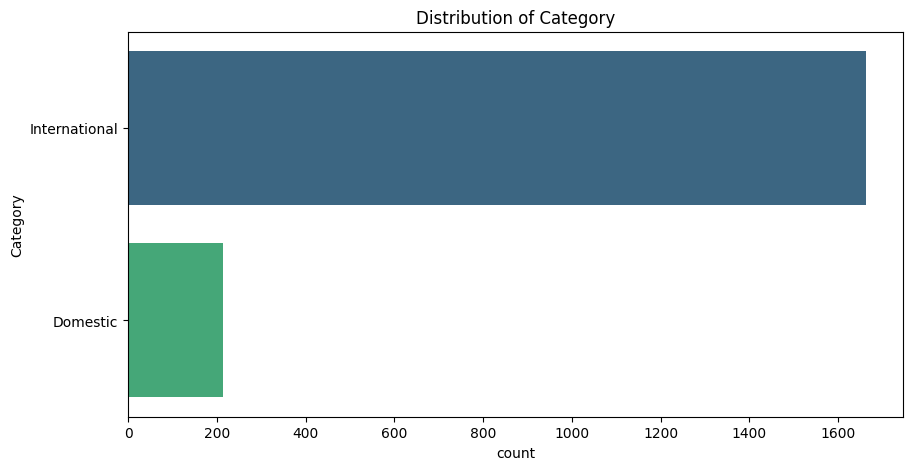


Unique values for Country:
Country
India           550
England         214
Australia       210
New Zealand     145
Sri Lanka       133
South Africa    125
West Indies     107
Afghanistan      90
Netherlands      72
Ireland          72
Bangladesh       50
USA              47
Nepal            41
Zimbabwe         22
Name: count, dtype: int64


/tmp/ipykernel_1239/2291289775.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_combined, order=df_combined[col].value_counts().index, palette='viridis')


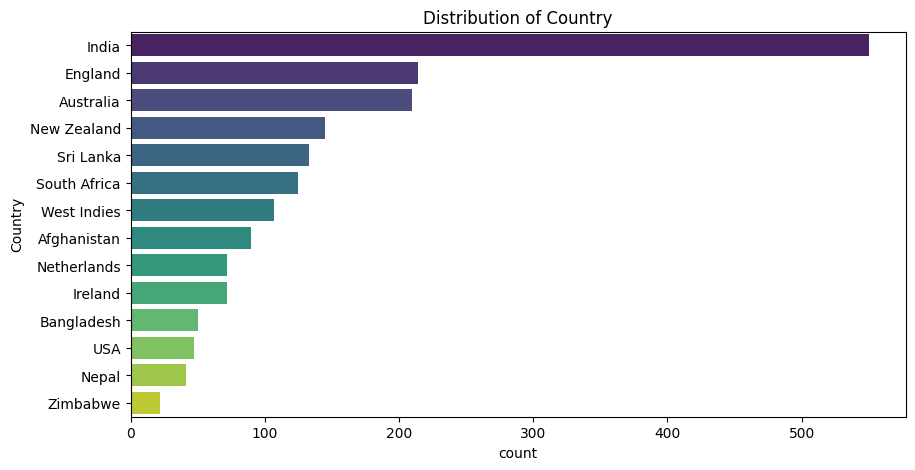


Unique values for Role:
Role
Batsman               440
Wk-Batsman            407
Pace Bowler           283
Fast-All Rounder      278
Spin-All Rounder      220
Spin Bowler           194
Medium Pace Bowler     30
Spin All Rounder       26
Name: count, dtype: int64


/tmp/ipykernel_1239/2291289775.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_combined, order=df_combined[col].value_counts().index, palette='viridis')


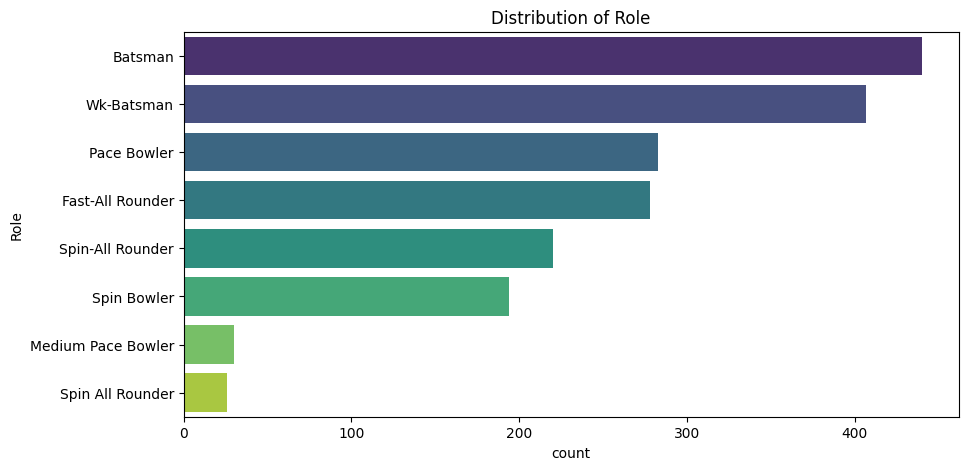


Unique values for Capped/Uncapped:
Capped/Uncapped
Capped      1547
Uncapped     331
Name: count, dtype: int64


/tmp/ipykernel_1239/2291289775.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_combined, order=df_combined[col].value_counts().index, palette='viridis')


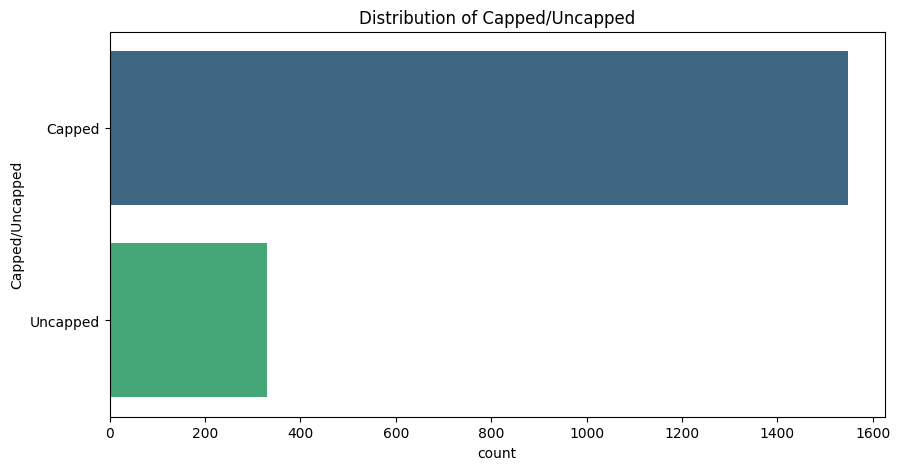


Unique values for Player_Value_Category:
Player_Value_Category
Mid Value     849
Low Value     734
High Value    295
Name: count, dtype: int64


/tmp/ipykernel_1239/2291289775.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_combined, order=df_combined[col].value_counts().index, palette='viridis')


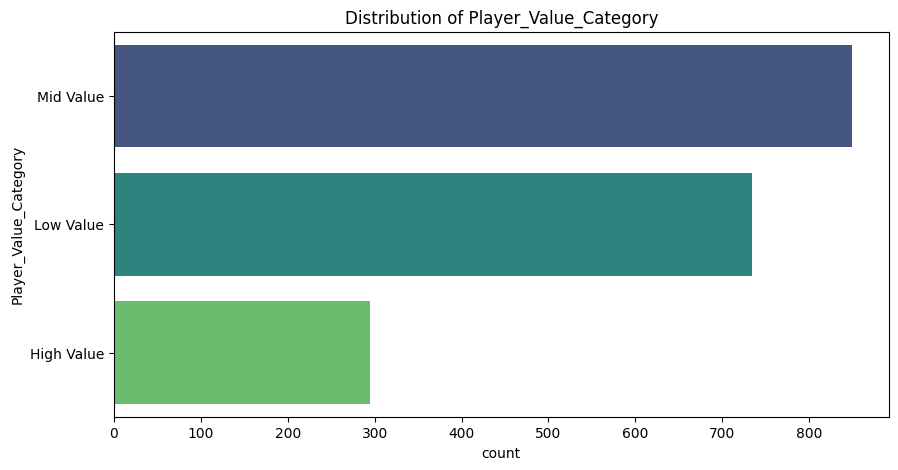

In [ ]:
categorical_cols = ['Category', 'Country', 'Role', 'Capped/Uncapped', 'Player_Value_Category']

for col in categorical_cols:
    if col in df_combined.columns:
        print(f"\nUnique values for {col}:")
        print(df_combined[col].value_counts())
        plt.figure(figsize=(10, 5))
        sns.countplot(y=col, data=df_combined, order=df_combined[col].value_counts().index, palette='viridis')
        plt.title(f'Distribution of {col}')
        plt.show()

### Numerical Feature Distribution

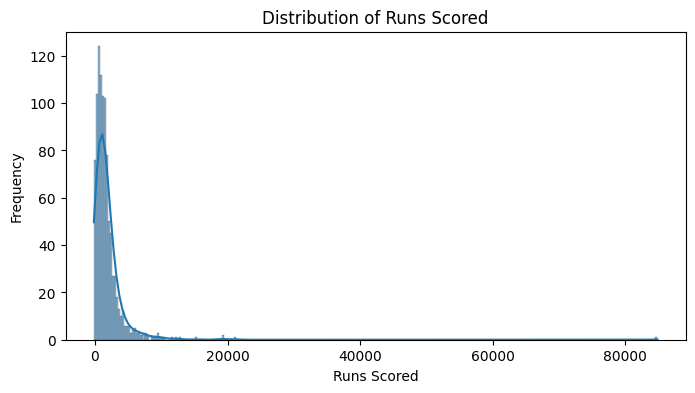

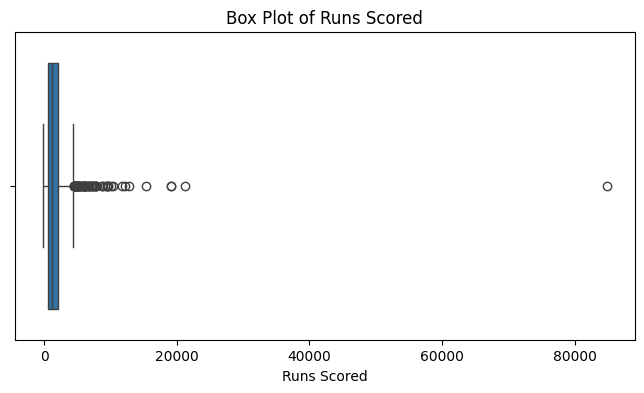

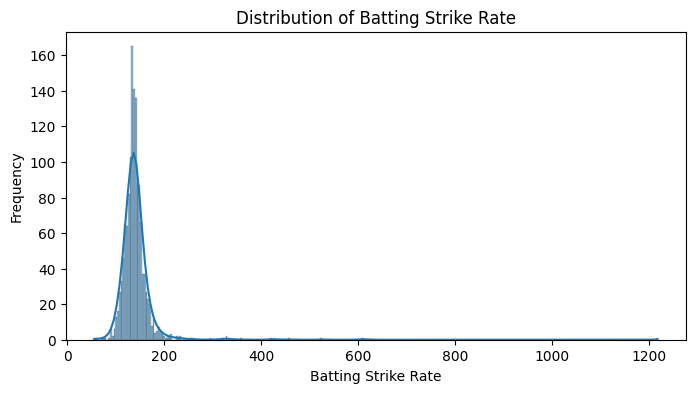

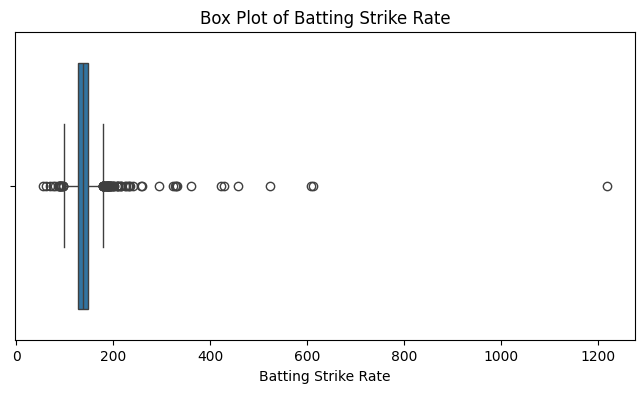

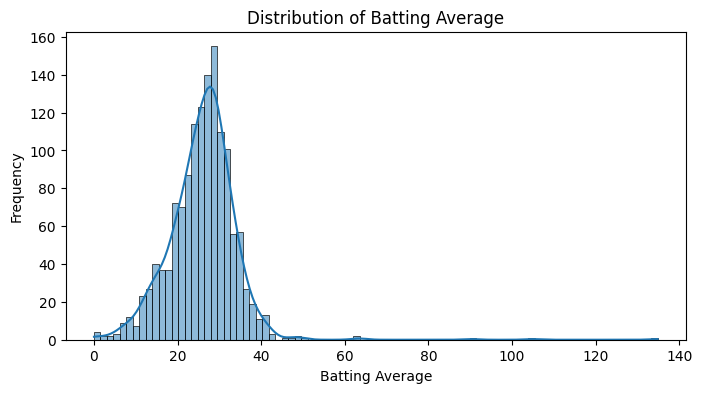

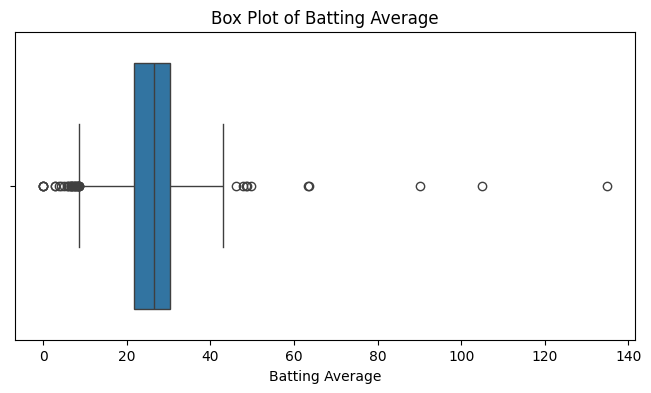

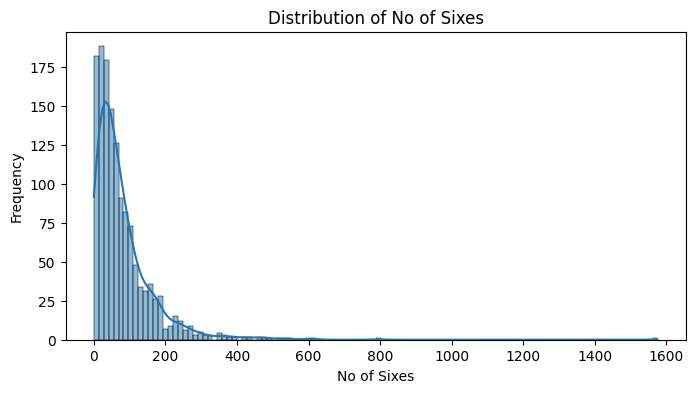

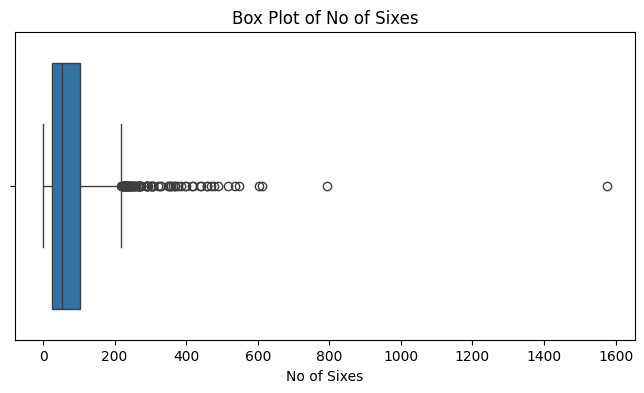

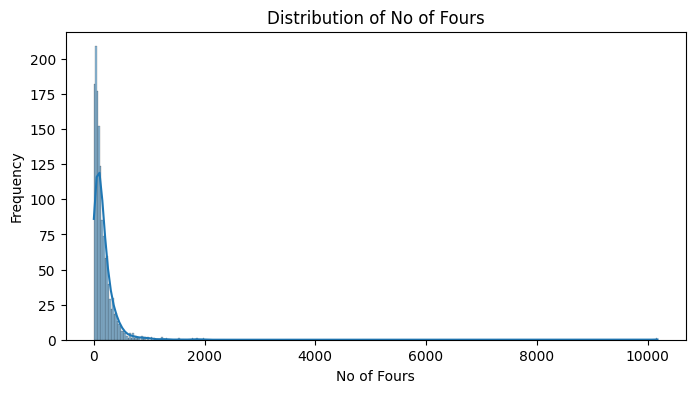

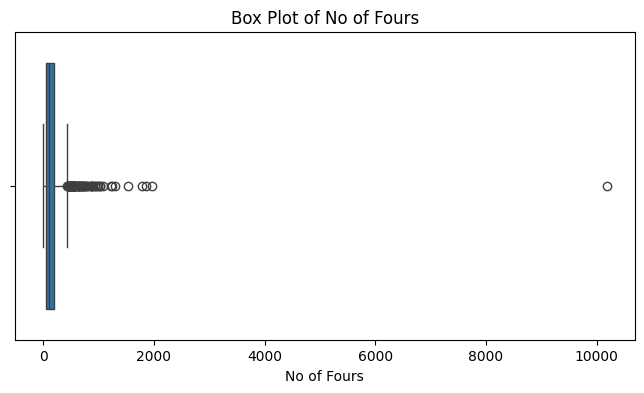

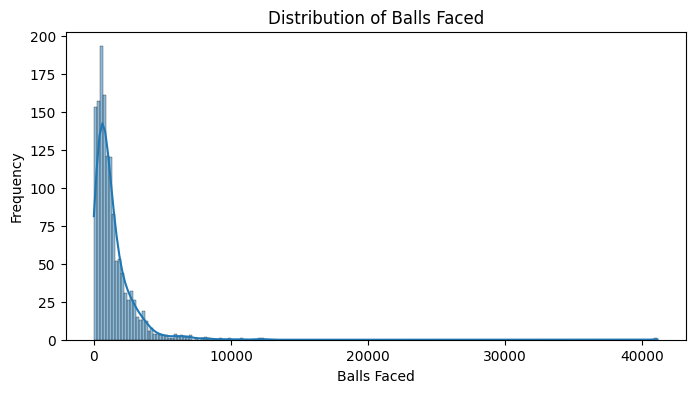

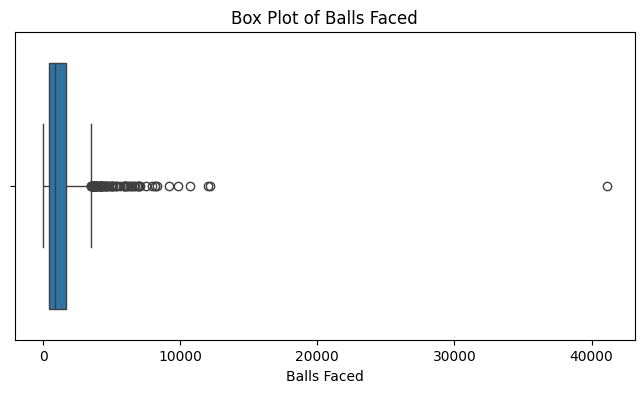

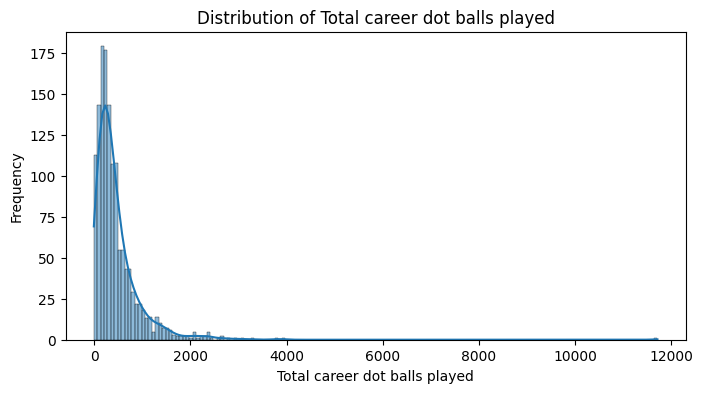

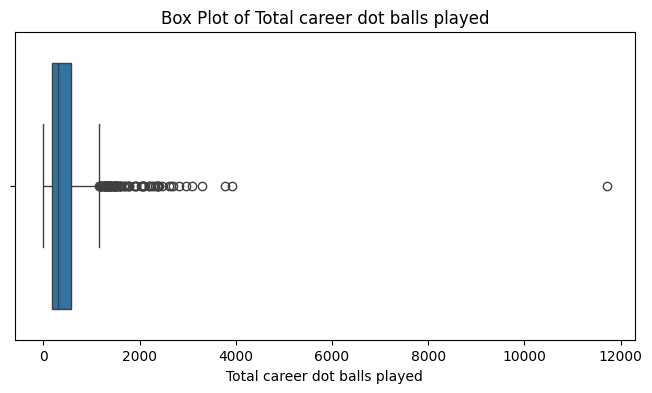

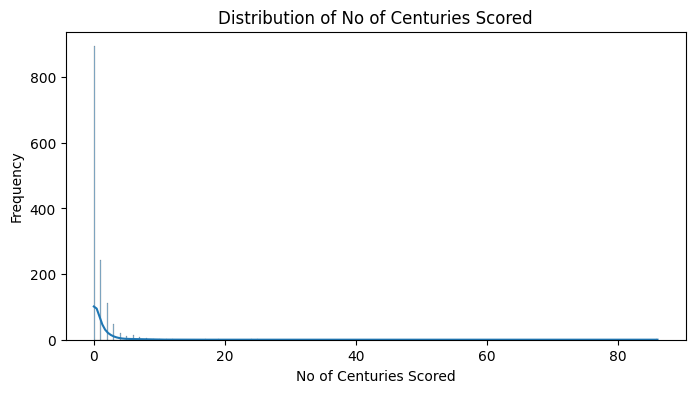

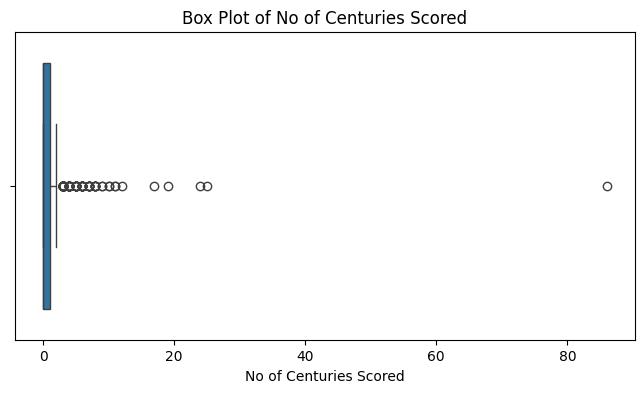

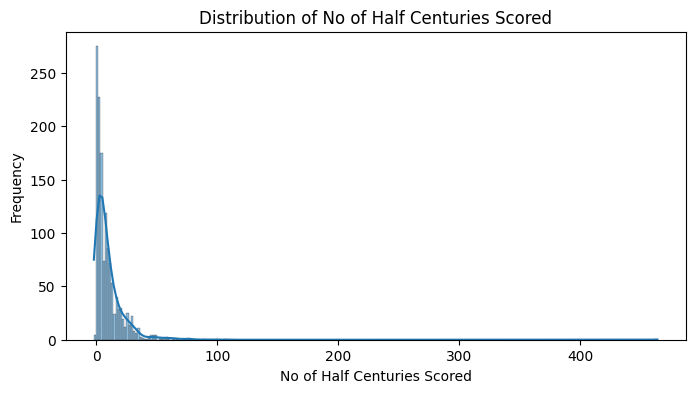

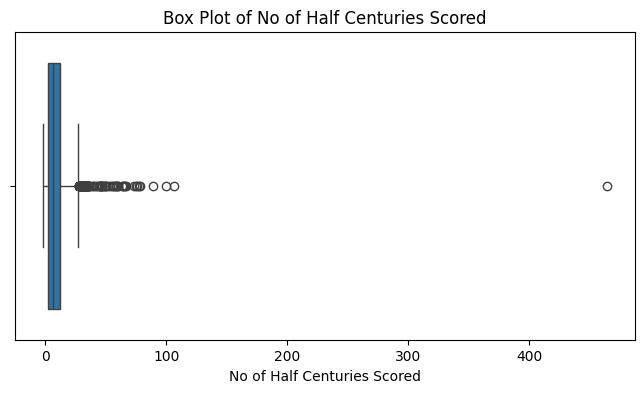

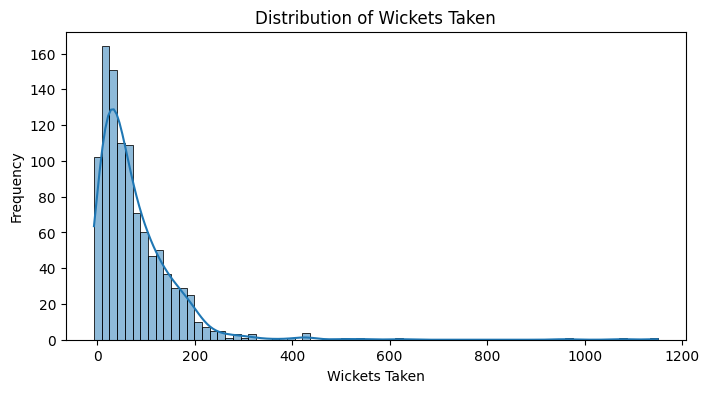

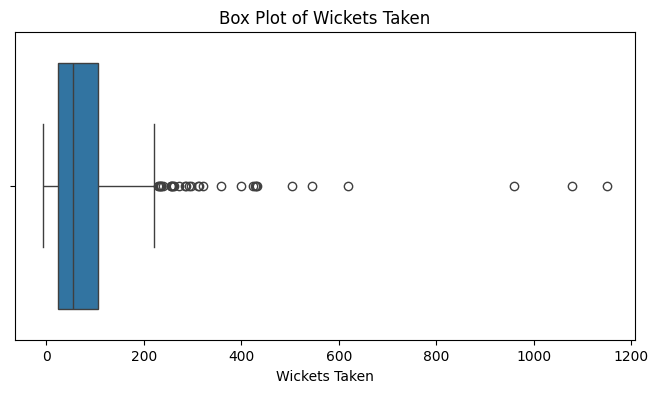

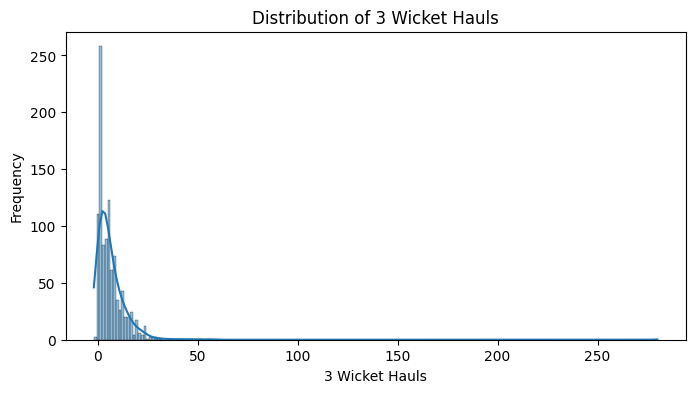

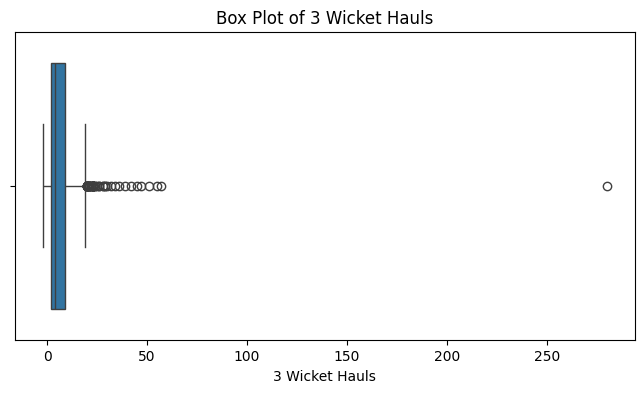

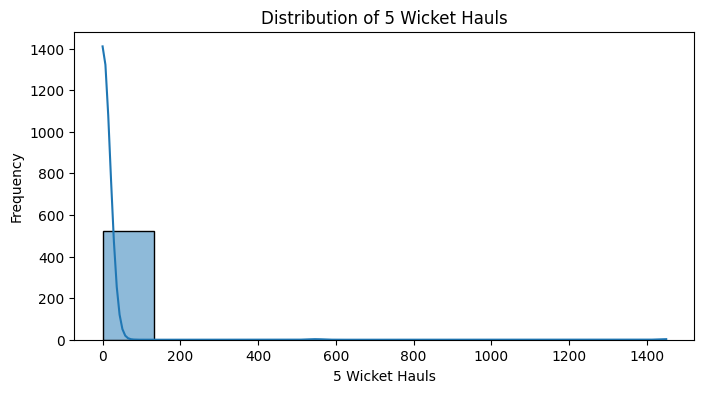

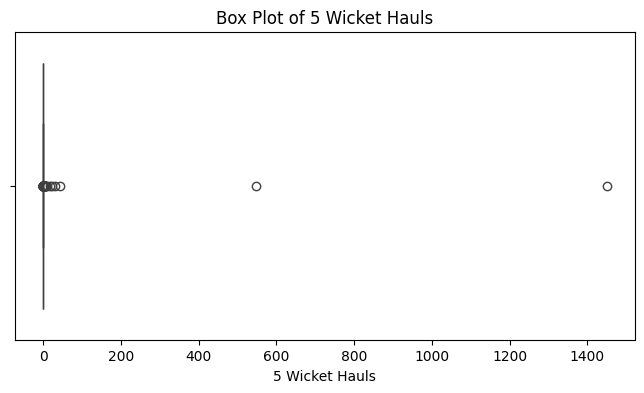

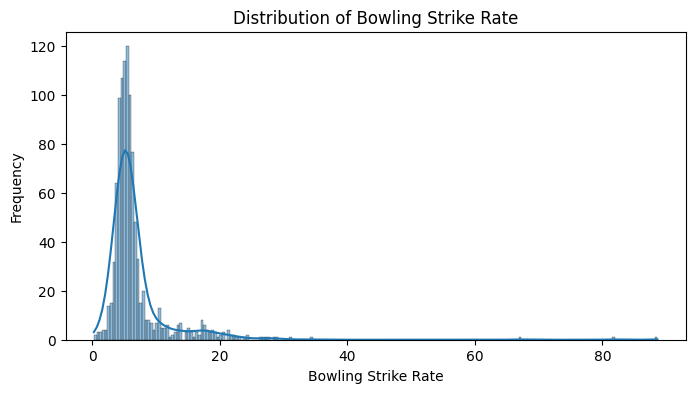

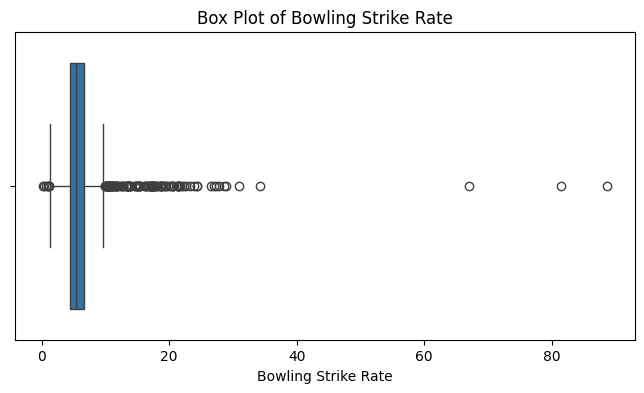

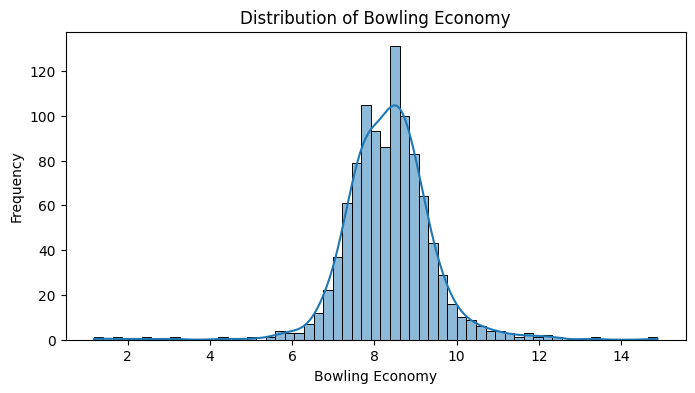

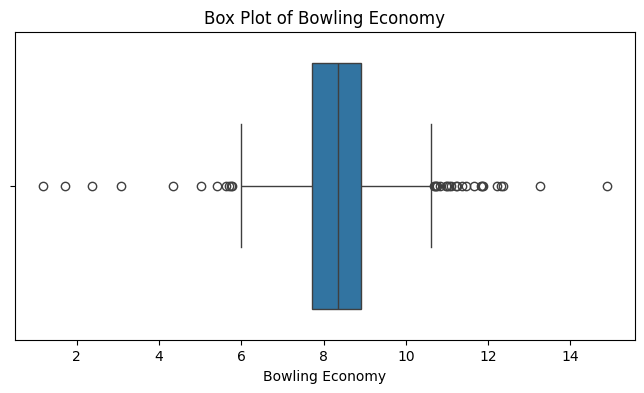

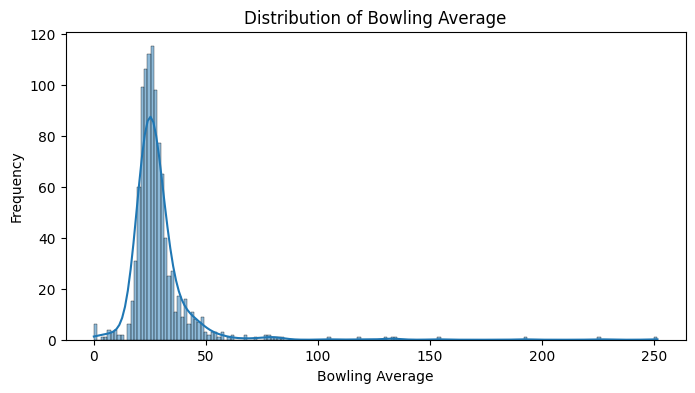

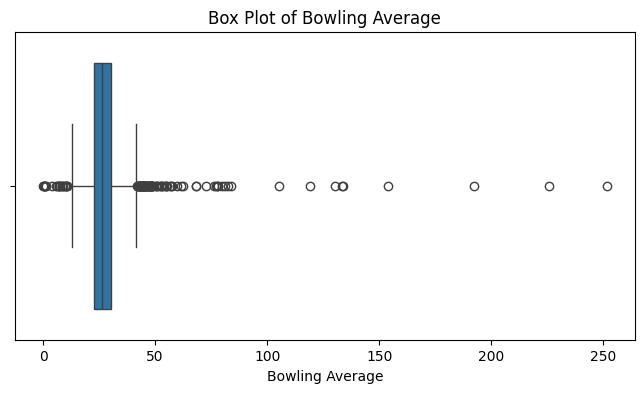

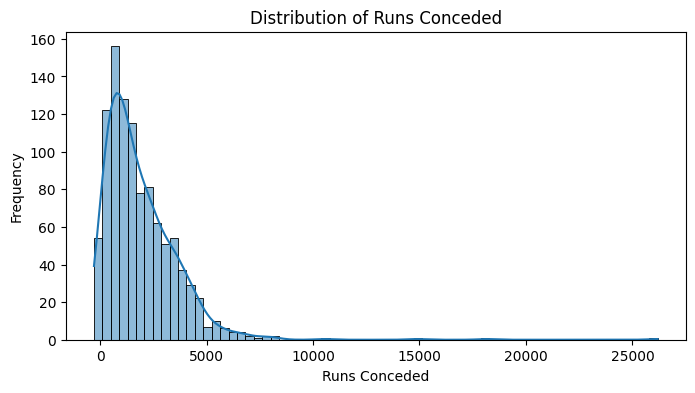

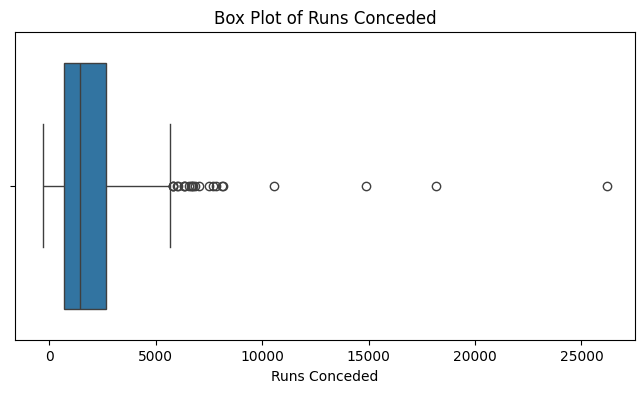

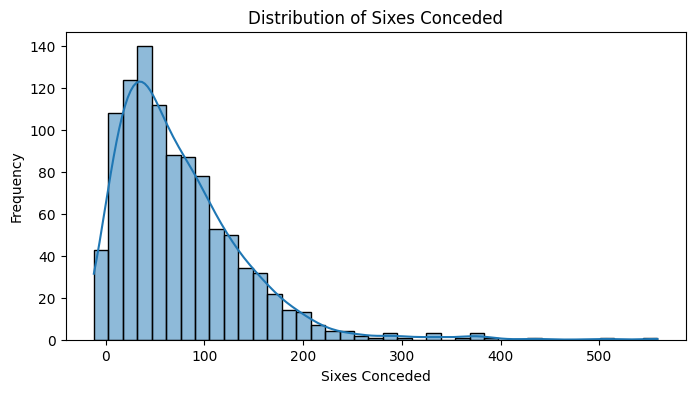

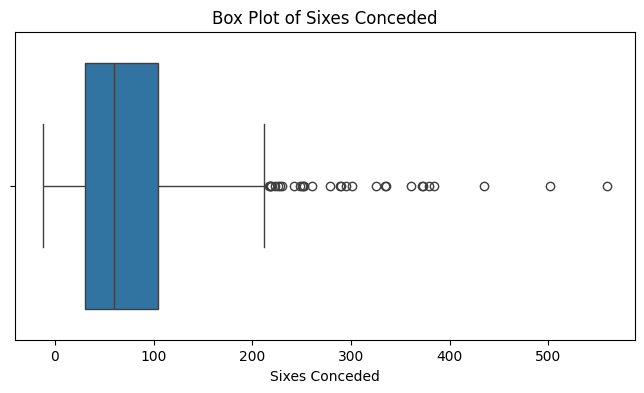

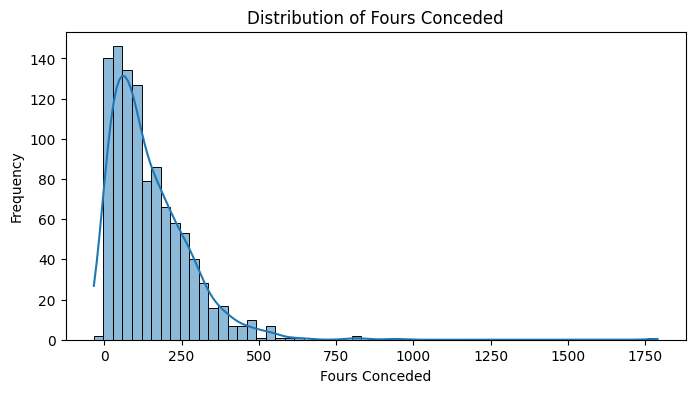

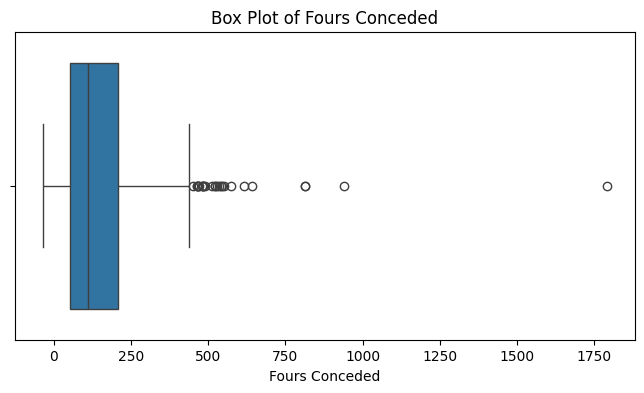

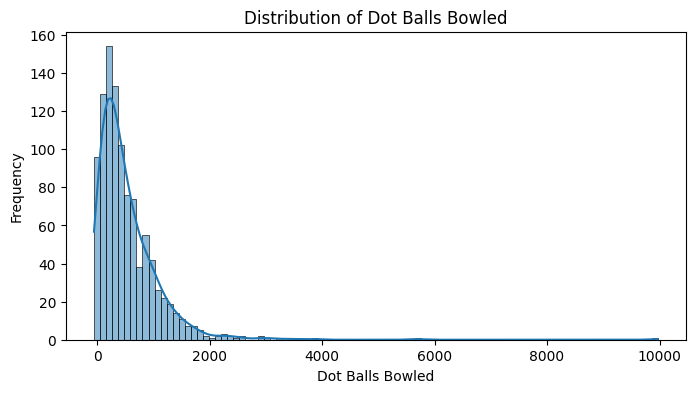

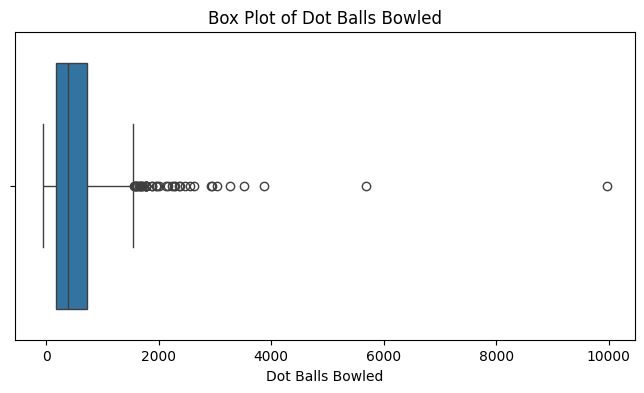

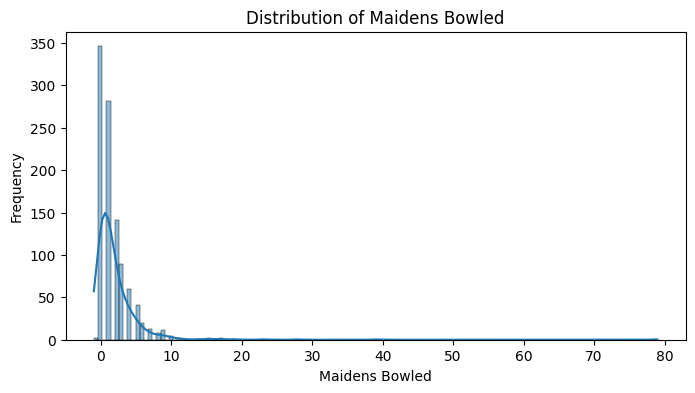

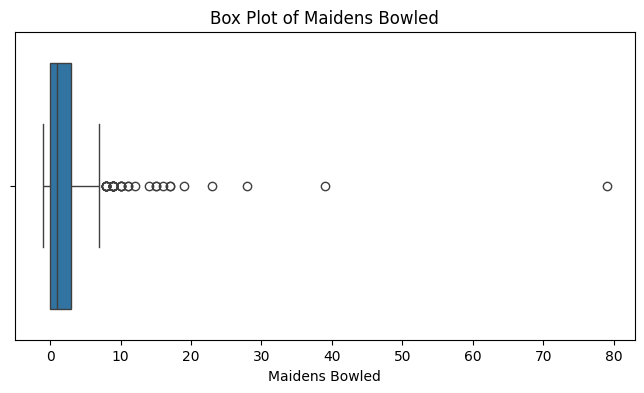

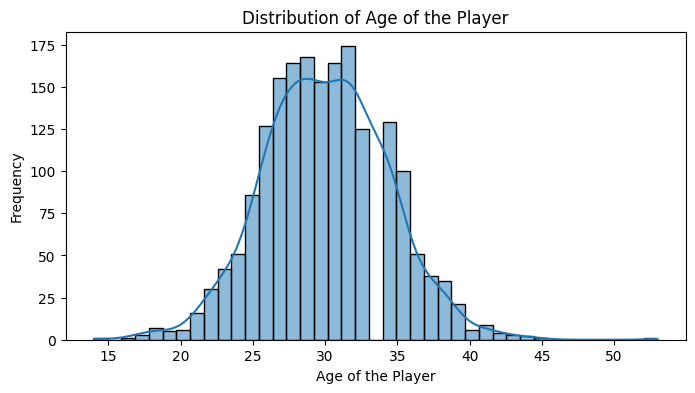

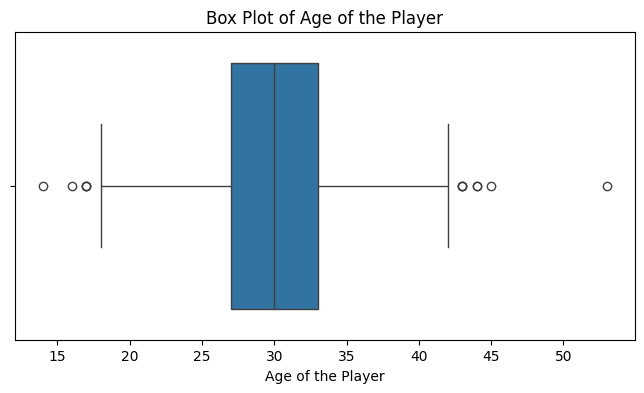

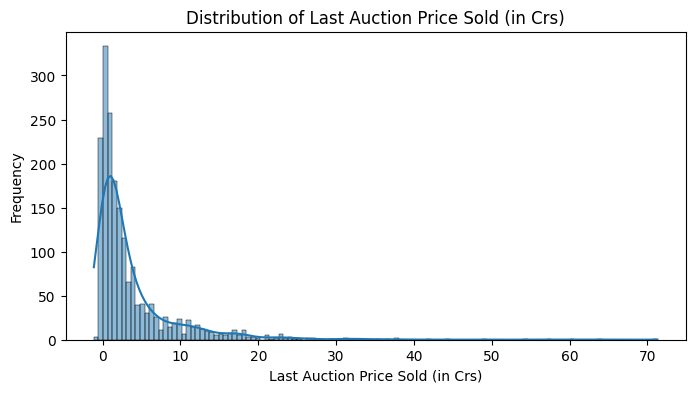

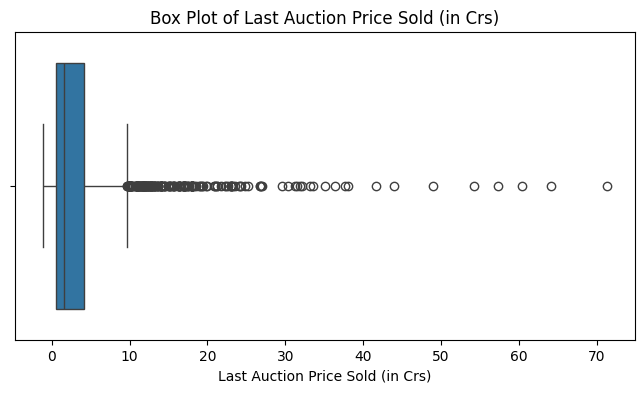

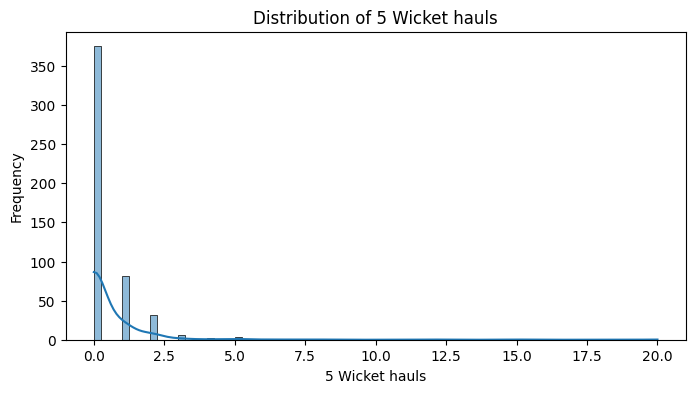

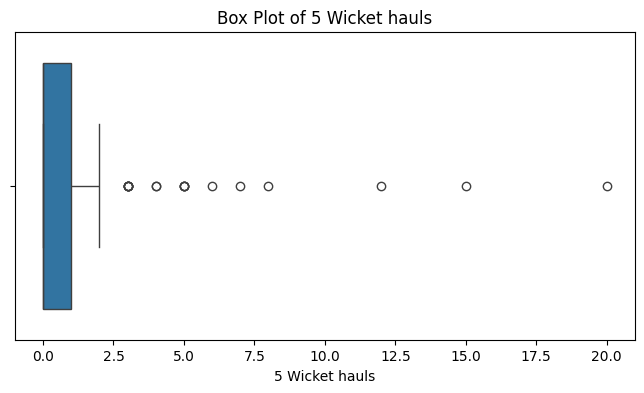

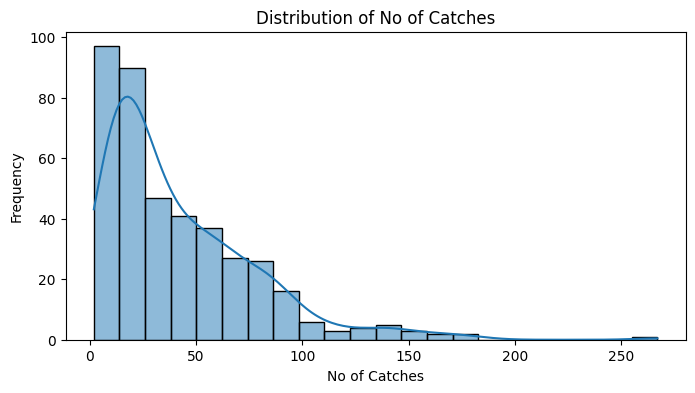

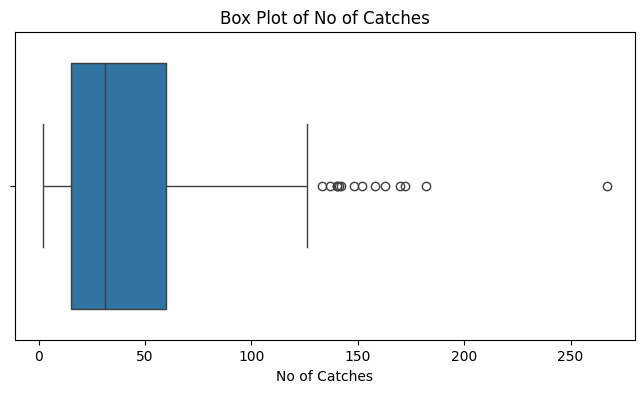

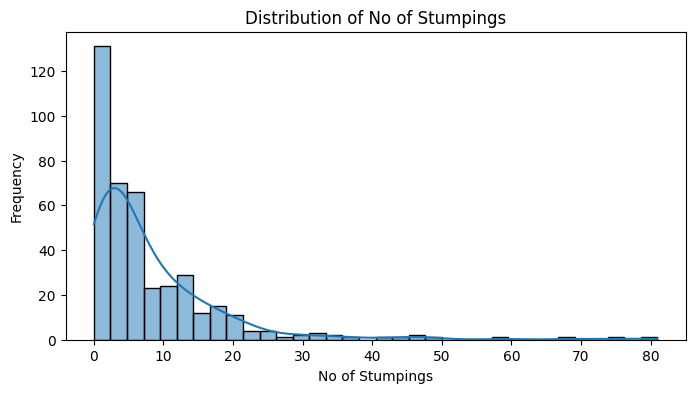

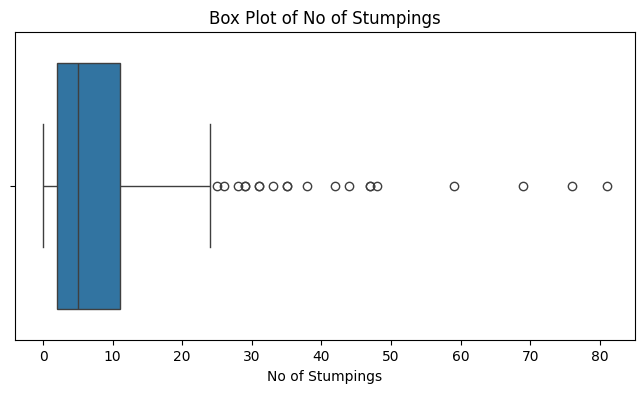

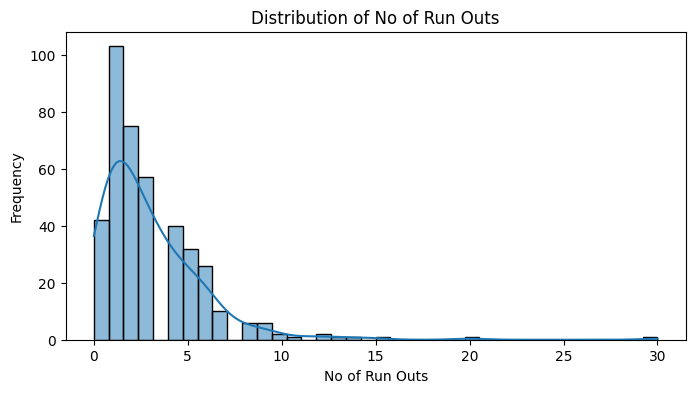

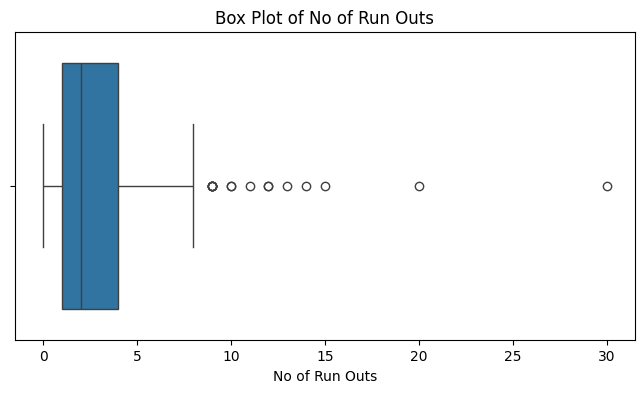

In [ ]:
numerical_cols = df_combined.select_dtypes(include=np.number).columns.tolist()
# Exclude 'Player_ID' if it was accidentally included and should not be plotted as a numerical distribution
if 'Player_ID' in numerical_cols:
    numerical_cols.remove('Player_ID')

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_combined[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_combined[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()

# *Final Squad*

In [ ]:


# Define High-Value threshold based on realistic auction economics
high_value_threshold = 7.0

# 1. Top 6 Batsmen (High Value + Top Strike Rate)
batsmen = df_combined[df_combined['Role'] == 'Batsman']
high_val_batsmen = batsmen[batsmen['Last Auction Price Sold (in Crs)'] >= high_value_threshold]
top_batsmen = high_val_batsmen.sort_values(by=['Batting Strike Rate', 'Runs Scored'], ascending=False).head(6)

# 2. Top 6 Bowlers (High Value + Low Economy)
bowlers = df_combined[df_combined['Role'].str.contains('Bowler', na=False)]
high_val_bowlers = bowlers[bowlers['Last Auction Price Sold (in Crs)'] >= high_value_threshold]
top_bowlers = high_val_bowlers.sort_values(by=['Bowling Economy', 'Wickets Taken'], ascending=[True, False]).head(6)

# 3. Top 5 All-Rounders (High Value + Balanced Metrics)
ar = df_combined[df_combined['Role'].str.contains('All Rounder', na=False)]
high_val_ar = ar[ar['Last Auction Price Sold (in Crs)'] >= high_value_threshold]
# Scoring All-Rounders: (Batting SR / Bowling Economy)
high_val_ar['AR_Score'] = high_val_ar['Batting Strike Rate'] / high_val_ar['Bowling Economy']
top_ar = high_val_ar.sort_values(by='AR_Score', ascending=False).head(5)

# 4. Top 3 Wicketkeepers (High Value + Batting Impact)
wks = df_combined[df_combined['Role'] == 'Wk-Batsman']
high_val_wks = wks[wks['Last Auction Price Sold (in Crs)'] >= high_value_threshold]
top_wks = high_val_wks.sort_values(by=['Batting Strike Rate', 'Batting Average'], ascending=False).head(3)

# Combine into the final squad of 20
squad = pd.concat([top_batsmen, top_bowlers, top_ar, top_wks])
squad_list = squad[['Player', 'Role', 'Country', 'Last Auction Price Sold (in Crs)']]

print(squad_list)

                    Player                Role       Country  \
1733            Player_206             Batsman         India   
1712            Player_185             Batsman         India   
1873            Player_346             Batsman     Australia   
1740            Player_213             Batsman         India   
1767            Player_240             Batsman         India   
1531              Player_4             Batsman         India   
524         Jasprit Bumrah         Pace Bowler         India   
610             Noor Ahmad         Spin Bowler   Afghanistan   
666              Player_36  Medium Pace Bowler     Australia   
535     Varun Chakravarthy         Spin Bowler         India   
813             Player_183         Spin Bowler         India   
930             Player_300         Pace Bowler         India   
226   Synthetic_Player_153    Fast-All Rounder     Australia   
240   Synthetic_Player_167    Fast-All Rounder     Australia   
152    Synthetic_Player_79    Fast-All R

/tmp/ipykernel_1239/4266587304.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_val_ar['AR_Score'] = high_val_ar['Batting Strike Rate'] / high_val_ar['Bowling Economy']


In [ ]:
squad_list

,Player,Role,Country,Last Auction Price Sold (in Crs)
1733,Player_206,Batsman,India,7.95
1712,Player_185,Batsman,India,7.08
1873,Player_346,Batsman,Australia,10.15
1740,Player_213,Batsman,India,9.62
1767,Player_240,Batsman,India,37.69
1531,Player_4,Batsman,India,11.02
524,Jasprit Bumrah,Pace Bowler,India,18.00
610,Noor Ahmad,Spin Bowler,Afghanistan,10.00
666,Player_36,Medium Pace Bowler,Australia,11.05
535,Varun Chakravarthy,Spin Bowler,India,12.00


In [ ]:
import pandas as pd
import numpy as np

file_path = '/content/drive/My Drive/Upgrad MS Datasets/Combined_Cricket_Data.csv'

# 3. Read the 4th sheet (index 3)
df = pd.read_csv(file_path)

df = df[~df['Player'].str.contains('Player_|Diff_', na=False)].reset_index(drop=True)

# 2. PREPROCESSING: Align columns and handle missing data
df['Price'] = pd.to_numeric(df['Last Auction Price Sold (in Crs)'], errors='coerce').fillna(0.2)
df['SR'] = pd.to_numeric(df['Batting Strike Rate'], errors='coerce').fillna(0)
df['Avg'] = pd.to_numeric(df['Batting Average'], errors='coerce').fillna(0)
df['Econ'] = pd.to_numeric(df['Bowling Economy'], errors='coerce').fillna(12.0)
df['Wkts'] = pd.to_numeric(df['Wickets Taken'], errors='coerce').fillna(0)

# 3. SCORING: Performance metrics derived from best-model insights
def calculate_score(row):
    role = str(row['Role']).lower()
    if 'batsman' in role:
        return row['SR'] * row['Avg']
    elif 'bowler' in role:
        return (row['Wkts'] + 1) / (row['Econ'] + 0.1) * 200
    elif 'all rounder' in role:
        return (row['SR'] * row['Avg'] / 5) + (row['Wkts'] * 50)
    elif 'wk' in role:
        # Standardize catch column check
        catches = row['No of Catches'] if 'No of Catches' in row and pd.notnull(row['No of Catches']) else 0
        return (row['SR'] * row['Avg']) + (catches * 5)
    return 0

df['Performance_Score'] = df.apply(calculate_score, axis=1)

# 4. SELECTION: Tactical balance with 120 Cr Purse
def build_squad(data, purse_limit=120.0):
    composition = {'Batsman': 8, 'Bowler': 8, 'All Rounder': 6, 'Wk-Batsman': 3, }
    squad_parts = []

    # Initial selection: Best performers per role
    for role_name, count in composition.items():
        role_mask = data['Role'].str.contains(role_name, case=False, na=False)
        candidates = data[role_mask].sort_values(by='Performance_Score', ascending=False)
        squad_parts.append(candidates.head(count))

    final_df = pd.concat(squad_parts).reset_index(drop=True)

    # 5. BUDGET ADJUSTMENT: Greedy replacement logic
    #
    while final_df['Price'].sum() > purse_limit:
        # Sort by price to find the most expensive player to drop
        final_df = final_df.sort_values(by='Price', ascending=False).reset_index(drop=True)

        # Use .at or .iloc to ensure we get a scalar string, not a Series
        expensive_price = final_df.iloc[0]['Price']
        role_to_replace = str(final_df.iloc[0]['Role'])

        # Find candidates in the same role not currently in the squad
        # Use a regex-safe version of the role name
        role_search_pattern = "Batsman" if "Batsman" in role_to_replace else \
                              "Bowler" if "Bowler" in role_to_replace else \
                              "All Rounder" if "All Rounder" in role_to_replace else "Wk"

        alt_mask = data['Role'].str.contains(role_search_pattern, case=False, na=False)
        current_squad_names = final_df['Player'].tolist()
        alternatives = data[alt_mask & (~data['Player'].isin(current_squad_names))].sort_values(by='Performance_Score', ascending=False)

        replacement_found = False
        for _, alt in alternatives.iterrows():
            if (final_df['Price'].sum() - expensive_price + alt['Price']) <= purse_limit:
                # Remove the expensive player (index 0 after sorting) and add the alternative
                final_df = pd.concat([final_df.iloc[1:], pd.DataFrame([alt])]).reset_index(drop=True)
                replacement_found = True
                break

        if not replacement_found:
            # If no top-performer fits the budget, pick the absolute cheapest available player in that role
            cheapest_alt = alternatives.sort_values(by='Price', ascending=True).iloc[0]
            final_df = pd.concat([final_df.iloc[1:], pd.DataFrame([cheapest_alt])]).reset_index(drop=True)

    return final_df

# Execute and Print
elite_squad = build_squad(df)
print(elite_squad[['Player', 'Role', 'Country', 'Performance_Score', 'Price']].sort_values(by='Role').to_string(index=False))
print(f"\nTotal Purse Spent: {elite_squad['Price'].sum():.2f} Crores")
print(f"Remaining Purse: {120.0 - elite_squad['Price'].sum():.2f} Crores")

                Player               Role      Country  Performance_Score  Price
          Brian Benett            Batsman     Zimbabwe        4757.295000   0.00
           Travis Head            Batsman    Australia        5904.100000  14.00
         Sai Sudharsan            Batsman        India        7266.780900   6.00
          Ayush Mhatre            Batsman        India        6480.124200   3.00
          Aaron George            Batsman        India       11077.500000   0.00
  Vaibhav Sooryavanshi            Batsman        India        7436.160000   1.10
          Aaron Hardie   Fast-All Rounder    Australia        9447.132000   1.25
           Daniel Sams   Fast-All Rounder    Australia       12399.240000   0.00
          Jason Holder   Fast-All Rounder  West Indies        8662.333684   7.00
         Mohammad Nabi   Fast-All Rounder  Afghanistan        9555.822222   1.50
            Tom Curran   Fast-All Rounder      England        9046.906329   1.39
     Bhuvneshwar Kumar Mediu

In [ ]:
import pandas as pd
import numpy as np


file_path = '/content/drive/My Drive/Upgrad MS Datasets/Combined_Cricket_Data.csv'

def generate_elite_squad_from_combined(file_path = file_path, purse_limit=120.0, os_limit=8):
    # 1. LOAD DATA: Using the single combined master dataset
    df = pd.read_csv(file_path)

    # 2. CLEANING: Remove synthetic/placeholder data (names with 'Player_' or 'Diff_')
    df = df[~df['Player'].str.contains('Player_|Diff_', na=False)].reset_index(drop=True)

    # 3. PREPROCESSING: Numeric conversion and column standardization
    # Standardize the price column name
    price_col = 'Last Auction Price Sold (in Crs)'

    df['Price'] = pd.to_numeric(df[price_col], errors='coerce').fillna(0.2)
    df['SR'] = pd.to_numeric(df['Batting Strike Rate'], errors='coerce').fillna(0)
    df['Avg'] = pd.to_numeric(df['Batting Average'], errors='coerce').fillna(0)
    df['Econ'] = pd.to_numeric(df['Bowling Economy'], errors='coerce').fillna(12.0)
    df['Wkts'] = pd.to_numeric(df['Wickets Taken'], errors='coerce').fillna(0)

    # Consolidate Runs (handles different column names from the merge)
    if 'Runs Scored' in df.columns and 'Batsmen Total Runs' in df.columns:
        df['Runs'] = pd.to_numeric(df['Runs Scored'].fillna(df['Batsmen Total Runs']), errors='coerce').fillna(0)
    else:
        # Fallback to whichever exists
        run_col = 'Runs Scored' if 'Runs Scored' in df.columns else 'Batsmen Total Runs'
        df['Runs'] = pd.to_numeric(df[run_col], errors='coerce').fillna(0)

    # Categorize Overseas Status
    df['Is_Overseas'] = df['Country'].apply(lambda x: 0 if str(x).lower() == 'india' else 1)

    # 4. SCORING: AI-driven metrics for each role
    def calculate_score(row):
        role = str(row['Role']).lower()
        if 'batsman' in role:
            return row['SR'] * row['Avg']
        elif 'bowler' in role:
            # Prioritize wickets and lower economy
            return (row['Wkts'] + 1) / (row['Econ'] + 0.1) * 200
        elif 'all rounder' in role:
            # Balanced score for multi-disciplinary impact
            return (row['SR'] * row['Avg'] / 5) + (row['Wkts'] * 50)
        elif 'wk' in role:
            # Batting impact + assumed keeping value
            catches = row['No of Catches'] if 'No of Catches' in df.columns and pd.notnull(row['No of Catches']) else 0
            return (row['SR'] * row['Avg']) + (catches * 5)
        return 0

    df['Score'] = df.apply(calculate_score, axis=1)

    # 5. INITIAL SELECTION: Tactical balance (6 Batsmen, 6 Bowlers, 5 All-Rounders, 3 Wicketkeepers)
    composition = {'Batsman': 6, 'Bowler': 6, 'All Rounder': 5, 'Wk-Batsman': 2}
    squad_parts = []
    for role_name, count in composition.items():
        role_mask = df['Role'].str.contains(role_name, case=False, na=False)
        squad_parts.append(df[role_mask].sort_values(by='Score', ascending=False).head(count))

    final_df = pd.concat(squad_parts).reset_index(drop=True)

    # 6. OPTIMIZATION: Greedy Swap Loop for Budget and Overseas limits
    iteration = 0
    while (final_df['Price'].sum() > purse_limit or final_df['Is_Overseas'].sum() > os_limit) and iteration < 100:
        iteration += 1
        # Sort by score ascending so we target the "least impact" players for replacement
        final_df = final_df.sort_values(by='Score', ascending=True).reset_index(drop=True)

        over_budget = final_df['Price'].sum() > purse_limit
        over_os = final_df['Is_Overseas'].sum() > os_limit

        # Selection logic for swapping
        if over_os:
            # Remove lowest-scoring overseas player, replace with best available Indian in same role
            os_players = final_df[final_df['Is_Overseas'] == 1].sort_values(by='Score', ascending=True)
            to_remove = os_players.iloc[0]
            role_pattern = "Batsman" if "Batsman" in to_remove['Role'] else "Bowler" if "Bowler" in to_remove['Role'] else "All Rounder" if "All Rounder" in to_remove['Role'] else "Wk"

            candidates = df[(df['Role'].str.contains(role_pattern, case=False, na=False)) &
                            (df['Is_Overseas'] == 0) &
                            (~df['Player'].isin(final_df['Player']))].sort_values(by='Score', ascending=False)
        else:
            # Remove most expensive player, replace with cheaper alternative in same role
            expensive_players = final_df.sort_values(by='Price', ascending=False)
            to_remove = expensive_players.iloc[0]
            role_pattern = "Batsman" if "Batsman" in to_remove['Role'] else "Bowler" if "Bowler" in to_remove['Role'] else "All Rounder" if "All Rounder" in to_remove['Role'] else "Wk"

            candidates = df[(df['Role'].str.contains(role_pattern, case=False, na=False)) &
                            (df['Price'] < to_remove['Price']) &
                            (~df['Player'].isin(final_df['Player']))].sort_values(by='Score', ascending=False)

        # Execute the swap
        if not candidates.empty:
            final_df = final_df[final_df['Player'] != to_remove['Player']]
            final_df = pd.concat([final_df, pd.DataFrame([candidates.iloc[0]])]).reset_index(drop=True)
        else:
            # Fallback: Emergency swap to absolute cheapest domestic player to free up space
            emergency_cand = df[(df['Role'].str.contains(role_pattern, case=False, na=False)) & (df['Is_Overseas'] == 0)].sort_values(by='Price').iloc[0]
            final_df = final_df[final_df['Player'] != to_remove['Player']]
            final_df = pd.concat([final_df, pd.DataFrame([emergency_cand])]).reset_index(drop=True)

    return final_df.sort_values(by=['Role', 'Score'], ascending=[True, False])

# --- EXECUTION ---
elite_squad = generate_elite_squad_from_combined()

# --- DISPLAY RESULTS ---
print("--- ELITE SQUAD SELECTION (120 CR LIMIT | MAX 8 OVERSEAS) ---")
print(elite_squad[['Player', 'Role', 'Country', 'Score', 'Price']].to_string(index=False))
print(f"\nTotal Purse Spent: {elite_squad['Price'].sum():.2f} Crores")
print(f"Overseas Players: {elite_squad['Is_Overseas'].sum()}")
print(f"Indian Players: {20 - elite_squad['Is_Overseas'].sum()}")

--- ELITE SQUAD SELECTION (120 CR LIMIT | MAX 8 OVERSEAS) ---
              Player               Role      Country        Score  Price
        Aaron George            Batsman        India 11077.500000   0.00
Vaibhav Sooryavanshi            Batsman        India  7436.160000   1.10
       Sai Sudharsan            Batsman        India  7266.780900   6.00
        Ayush Mhatre            Batsman        India  6480.124200   3.00
         Travis Head            Batsman    Australia  5904.100000  14.00
         Daniel Sams   Fast-All Rounder    Australia 12399.240000   0.00
       Mohammad Nabi   Fast-All Rounder  Afghanistan  9555.822222   1.50
        Aaron Hardie   Fast-All Rounder    Australia  9447.132000   1.25
          Tom Curran   Fast-All Rounder      England  9046.906329   1.39
   Bhuvneshwar Kumar Medium Pace Bowler        India  5109.114249  10.75
       Harshal Patel Medium Pace Bowler        India  3392.857143   8.00
      Jasprit Bumrah        Pace Bowler        India  5054.054

In [ ]:
import pandas as pd
import numpy as np

def generate_elite_squad_v2(file_path='/content/drive/My Drive/Upgrad MS Datasets/Combined_Cricket_Data.csv'):
    # 1. LOAD DATA
    df = pd.read_csv(file_path)

    # 2. CLEANING: Remove synthetic/placeholder and duplicates from source
    df = df[~df['Player'].str.contains('Player_|Diff_', na=False)]
    df = df.drop_duplicates(subset=['Player']).reset_index(drop=True)

    # 3. PREPROCESSING: Numeric conversion
    price_col = 'Last Auction Price Sold (in Crs)'
    df['Price'] = pd.to_numeric(df[price_col], errors='coerce').fillna(0.2)
    df['SR'] = pd.to_numeric(df['Batting Strike Rate'], errors='coerce').fillna(0)
    df['Avg'] = pd.to_numeric(df['Batting Average'], errors='coerce').fillna(0)
    df['Econ'] = pd.to_numeric(df['Bowling Economy'], errors='coerce').fillna(12.0)
    df['Wkts'] = pd.to_numeric(df['Wickets Taken'], errors='coerce').fillna(0)

    # Consolidate Runs
    run_col = 'Runs Scored' if 'Runs Scored' in df.columns else 'Batsmen Total Runs'
    df['Runs'] = pd.to_numeric(df[run_col], errors='coerce').fillna(0)

    # Overseas Mapping
    df['Is_Overseas'] = df['Country'].apply(lambda x: 0 if str(x).lower() == 'india' else 1)

    # 4. SCORING ENGINE (Based on AI Findings)
    def calculate_score(row):
        role = str(row['Role']).lower()
        if 'batsman' in role:
            return row['SR'] * row['Avg']
        elif 'bowler' in role:
            return (row['Wkts'] + 1) / (row['Econ'] + 0.1) * 200
        elif 'all rounder' in role:
            return (row['SR'] * row['Avg'] / 5) + (row['Wkts'] * 50)
        elif 'wk' in role:
            return (row['SR'] * row['Avg']) + 50 # Base keeping bonus
        return 0

    df['Score'] = df.apply(calculate_score, axis=1)

    # 5. INITIAL SELECTION: 20 Players (6 Bat, 6 Bowl, 5 AR, 3 WK)
    composition = {'Batsman': 6, 'Bowler': 6, 'All Rounder': 5, 'Wk-Batsman': 3}
    final_df = pd.DataFrame()

    for role_name, count in composition.items():
        role_mask = df['Role'].str.contains(role_name, case=False, na=False)
        # Prevent picking same player across different roles
        available = df[role_mask & (~df['Player'].isin(final_df['Player'] if not final_df.empty else []))]
        selected = available.sort_values(by='Score', ascending=False).head(count)
        final_df = pd.concat([final_df, selected])

    # 6. HARD CONSTRAINT OPTIMIZATION
    purse_limit = 120.0
    os_limit = 8

    iteration = 0
    # Loop runs until both conditions are met
    while (final_df['Price'].sum() > purse_limit or final_df['Is_Overseas'].sum() > os_limit) and iteration < 200:
        iteration += 1
        final_df = final_df.reset_index(drop=True)

        # Priority 1: Fix Overseas Limit
        if final_df['Is_Overseas'].sum() > os_limit:
            # Swap lowest scoring OS player for best available Indian player in same role
            os_list = final_df[final_df['Is_Overseas'] == 1].sort_values(by='Score', ascending=True)
            to_remove = os_list.iloc[0]
            role_search = "Batsman" if "Batsman" in to_remove['Role'] else "Bowler" if "Bowler" in to_remove['Role'] else "All Rounder" if "All Rounder" in to_remove['Role'] else "Wk"

            candidates = df[(df['Role'].str.contains(role_search, case=False, na=False)) &
                            (df['Is_Overseas'] == 0) &
                            (~df['Player'].isin(final_df['Player']))].sort_values(by='Score', ascending=False)

        # Priority 2: Fix Budget Limit
        else:
            # Swap the player with the worst "Score per Crore" efficiency
            final_df['Efficiency'] = final_df['Score'] / final_df['Price']
            to_remove = final_df.sort_values(by='Efficiency', ascending=True).iloc[0]
            role_search = "Batsman" if "Batsman" in to_remove['Role'] else "Bowler" if "Bowler" in to_remove['Role'] else "All Rounder" if "All Rounder" in to_remove['Role'] else "Wk"

            candidates = df[(df['Role'].str.contains(role_search, case=False, na=False)) &
                            (df['Price'] < to_remove['Price']) &
                            (~df['Player'].isin(final_df['Player']))].sort_values(by='Score', ascending=False)

        if not candidates.empty:
            final_df = final_df[final_df['Player'] != to_remove['Player']]
            final_df = pd.concat([final_df, pd.DataFrame([candidates.iloc[0]])])
        else:
            # Emergency: replace with cheapest available Indian player in that role
            emergency = df[(df['Role'].str.contains(role_search, case=False, na=False)) &
                           (df['Is_Overseas'] == 0) &
                           (~df['Player'].isin(final_df['Player']))].sort_values(by='Price').iloc[0]
            final_df = final_df[final_df['Player'] != to_remove['Player']]
            final_df = pd.concat([final_df, pd.DataFrame([emergency])])

    return final_df.sort_values(by=['Role', 'Score'], ascending=[True, False])

# --- EXECUTION ---
elite_squad = generate_elite_squad_v2()

# --- VALIDATION DISPLAY ---
print("--- FINAL SQUAD: 120 CR LIMIT | NO DUPLICATES | MAX 8 OVERSEAS ---")
print(elite_squad[['Player', 'Role', 'Country', 'Score', 'Price']].to_string(index=False))
print(f"\n--- SQUAD STATS ---")
print(f"Total Purse Spent: {elite_squad['Price'].sum():.2f} Crores")
print(f"Overseas Count: {elite_squad['Is_Overseas'].sum()} / 8")
print(f"Unique Player Check: {elite_squad['Player'].nunique()} / 20")

--- FINAL SQUAD: 120 CR LIMIT | NO DUPLICATES | MAX 8 OVERSEAS ---
              Player               Role      Country        Score  Price
        Aaron George            Batsman        India 11077.500000   0.00
Vaibhav Sooryavanshi            Batsman        India  7436.160000   1.10
       Sai Sudharsan            Batsman        India  7266.780900   6.00
        Ayush Mhatre            Batsman        India  6480.124200   3.00
         Travis Head            Batsman    Australia  5904.100000  14.00
     Ruturaj Gaikwad            Batsman        India  5546.914500  18.00
        Shubman Gill            Batsman        India  5472.504000  16.35
         Daniel Sams   Fast-All Rounder    Australia 12399.240000   0.00
       Mohammad Nabi   Fast-All Rounder  Afghanistan  9555.822222   1.50
        Aaron Hardie   Fast-All Rounder    Australia  9447.132000   1.25
          Tom Curran   Fast-All Rounder      England  9046.906329   1.39
   Bhuvneshwar Kumar Medium Pace Bowler        India  510

In [ ]:
import pandas as pd
import numpy as np

def generate_strict_elite_squad(file_path='/content/drive/My Drive/Upgrad MS Datasets/Combined_Cricket_Data.csv', purse_limit=120.0, os_limit=8):
    # 1. LOAD DATA: Using the consolidated master dataset
    df = pd.read_csv(file_path)

    # 2. CLEANING: Purge synthetic entries and ensure unique player entries
    # Synthetic names typically follow 'Player_X' or 'Diff_Player_X' patterns
    df = df[~df['Player'].str.contains('Player_|Diff_', na=False)]
    df = df.drop_duplicates(subset=['Player']).reset_index(drop=True)

    # 3. PREPROCESSING: Align columns and handle missing data
    price_col = 'Last Auction Price Sold (in Crs)'
    df['Price'] = pd.to_numeric(df[price_col], errors='coerce').fillna(0.2)
    df['SR'] = pd.to_numeric(df['Batting Strike Rate'], errors='coerce').fillna(0)
    df['Avg'] = pd.to_numeric(df['Batting Average'], errors='coerce').fillna(0)
    df['Econ'] = pd.to_numeric(df['Bowling Economy'], errors='coerce').fillna(12.0)
    df['Wkts'] = pd.to_numeric(df['Wickets Taken'], errors='coerce').fillna(0)

    # Consolidate Runs (handles different source column names)
    run_col = 'Runs Scored' if 'Runs Scored' in df.columns else 'Batsmen Total Runs'
    df['Runs'] = pd.to_numeric(df[run_col], errors='coerce').fillna(0)

    # Overseas Mapping (Any country other than India is Overseas)
    df['Is_Overseas'] = df['Country'].apply(lambda x: 0 if str(x).lower() == 'india' else 1)

    # 4. SCORING ENGINE: Performance metrics derived from best-performing AI model insights
    # These functions prioritize efficiency (SR/Economy) over simple volume
    def calculate_score(row):
        role = str(row['Role']).lower()
        if 'batsman' in role:
            return row['SR'] * row['Avg']
        elif 'bowler' in role:
            return (row['Wkts'] + 1) / (row['Econ'] + 0.1) * 200
        elif 'all rounder' in role:
            return (row['SR'] * row['Avg'] / 5) + (row['Wkts'] * 50)
        elif 'wk' in role:
            return (row['SR'] * row['Avg']) + 50 # Base keeper utility bonus
        return 0

    df['Score'] = df.apply(calculate_score, axis=1)

    # 5. INITIAL SELECTION: Tactical balance (6 Bat, 6 Bowl, 5 AR, 3 WK)
    composition = {'Batsman': 6, 'Bowler': 6, 'All Rounder': 5, 'Wk-Batsman': 3}
    final_df = pd.DataFrame()

    for role_name, count in composition.items():
        role_mask = df['Role'].str.contains(role_name, case=False, na=False)
        # Exclude players already in the squad to prevent role duplication
        available = df[role_mask & (~df['Player'].isin(final_df['Player'] if not final_df.empty else []))]
        selected = available.sort_values(by='Score', ascending=False).head(count)
        final_df = pd.concat([final_df, selected])

    # 6. HARD CONSTRAINT OPTIMIZATION: Greedy Swap Logic
    #
    iteration = 0
    while (final_df['Price'].sum() > purse_limit or final_df['Is_Overseas'].sum() > os_limit) and iteration < 200:
        iteration += 1
        final_df = final_df.reset_index(drop=True)

        over_budget = final_df['Price'].sum() > purse_limit
        over_os = final_df['Is_Overseas'].sum() > os_limit

        # Priority 1: Enforce Overseas Limit
        if over_os:
            # Replace lowest-scoring OS player with best available Indian player of the same role
            os_players = final_df[final_df['Is_Overseas'] == 1].sort_values(by='Score', ascending=True)
            to_remove = os_players.iloc[0]
            role_patt = "Batsman" if "Batsman" in to_remove['Role'] else "Bowler" if "Bowler" in to_remove['Role'] else "All Rounder" if "All Rounder" in to_remove['Role'] else "Wk"

            candidates = df[(df['Role'].str.contains(role_patt, case=False, na=False)) &
                            (df['Is_Overseas'] == 0) &
                            (~df['Player'].isin(final_df['Player']))].sort_values(by='Score', ascending=False)

        # Priority 2: Enforce Purse Limit
        else:
            # Replace least price-efficient player (Score/Price) with a cheaper alternative in same role
            final_df['Efficiency'] = final_df['Score'] / (final_df['Price'] + 0.1)
            to_remove = final_df.sort_values(by='Efficiency', ascending=True).iloc[0]
            role_patt = "Batsman" if "Batsman" in to_remove['Role'] else "Bowler" if "Bowler" in to_remove['Role'] else "All Rounder" if "All Rounder" in to_remove['Role'] else "Wk"

            candidates = df[(df['Role'].str.contains(role_patt, case=False, na=False)) &
                            (df['Price'] < to_remove['Price']) &
                            (~df['Player'].isin(final_df['Player']))].sort_values(by='Score', ascending=False)

        # Execute Swap
        if not candidates.empty:
            final_df = final_df[final_df['Player'] != to_remove['Player']]
            final_df = pd.concat([final_df, pd.DataFrame([candidates.iloc[0]])])
        else:
            # Emergency: replace with absolute cheapest domestic player to ensure constraints are met
            emergency = df[(df['Role'].str.contains(role_patt, case=False, na=False)) &
                           (df['Is_Overseas'] == 0) &
                           (~df['Player'].isin(final_df['Player']))].sort_values(by='Price').iloc[0]
            final_df = final_df[final_df['Player'] != to_remove['Player']]
            final_df = pd.concat([final_df, pd.DataFrame([emergency])])

    return final_df.sort_values(by=['Role', 'Score'], ascending=[True, False]).reset_index(drop=True)

# --- EXECUTION ---
elite_squad = generate_strict_elite_squad()

# --- VALIDATION DISPLAY ---
print("--- ELITE SQUAD SELECTION (120 CR LIMIT | 8 OS LIMIT | NO SYNTHETIC DATA) ---")
print(elite_squad[['Player', 'Role', 'Country', 'Score', 'Price']].to_string(index=False))

--- ELITE SQUAD SELECTION (120 CR LIMIT | 8 OS LIMIT | NO SYNTHETIC DATA) ---
              Player               Role      Country        Score  Price
        Aaron George            Batsman        India 11077.500000   0.00
Vaibhav Sooryavanshi            Batsman        India  7436.160000   1.10
       Sai Sudharsan            Batsman        India  7266.780900   6.00
        Ayush Mhatre            Batsman        India  6480.124200   3.00
         Travis Head            Batsman    Australia  5904.100000  14.00
     Ruturaj Gaikwad            Batsman        India  5546.914500  18.00
        Shubman Gill            Batsman        India  5472.504000  16.35
         Daniel Sams   Fast-All Rounder    Australia 12399.240000   0.00
       Mohammad Nabi   Fast-All Rounder  Afghanistan  9555.822222   1.50
        Aaron Hardie   Fast-All Rounder    Australia  9447.132000   1.25
          Tom Curran   Fast-All Rounder      England  9046.906329   1.39
   Bhuvneshwar Kumar Medium Pace Bowler       

In [ ]:
import pandas as pd
import numpy as np

def generate_strict_elite_squad(file_path='/content/drive/My Drive/Upgrad MS Datasets/Combined_Cricket_Data.csv', purse_limit=120.0, os_limit=8):
    # 1. LOAD DATA
    df = pd.read_csv(file_path)

    # 2. CLEANING: Purge synthetic entries and ensure unique player entries
    df = df[~df['Player'].str.contains('Player_|Diff_', na=False)]
    df = df.drop_duplicates(subset=['Player']).reset_index(drop=True)

    # 3. PREPROCESSING: Align columns and handle missing data
    price_col = 'Last Auction Price Sold (in Crs)'
    df['Price'] = pd.to_numeric(df[price_col], errors='coerce').fillna(0.2)
    df['SR'] = pd.to_numeric(df['Batting Strike Rate'], errors='coerce').fillna(0)
    df['Avg'] = pd.to_numeric(df['Batting Average'], errors='coerce').fillna(0)
    df['Econ'] = pd.to_numeric(df['Bowling Economy'], errors='coerce').fillna(12.0)
    df['Wkts'] = pd.to_numeric(df['Wickets Taken'], errors='coerce').fillna(0)

    run_col = 'Runs Scored' if 'Runs Scored' in df.columns else 'Batsmen Total Runs'
    df['Runs'] = pd.to_numeric(df[run_col], errors='coerce').fillna(0)
    df['Is_Overseas'] = df['Country'].apply(lambda x: 0 if str(x).lower() == 'india' else 1)

    # 4. SCORING ENGINE
    def calculate_score(row):
        role = str(row['Role']).lower()
        if 'batsman' in role:
            return row['SR'] * row['Avg']
        elif 'bowler' in role:
            return (row['Wkts'] + 1) / (row['Econ'] + 0.1) * 200
        elif 'all rounder' in role:
            return (row['SR'] * row['Avg'] / 5) + (row['Wkts'] * 50)
        elif 'wk' in role:
            return (row['SR'] * row['Avg']) + 50
        return 0

    df['Score'] = df.apply(calculate_score, axis=1)

    # 5. INITIAL SELECTION: Tactical balance (6 Bat, 6 Bowl, 5 AR, 3 WK)
    composition = {'Batsman': 5, 'Bowler': 5, 'All Rounder': 5, 'Wk-Batsman': 3}
    final_df = pd.DataFrame()

    for role_name, count in composition.items():
        role_mask = df['Role'].str.contains(role_name, case=False, na=False)
        available = df[role_mask & (~df['Player'].isin(final_df['Player'] if not final_df.empty else []))]
        selected = available.sort_values(by='Score', ascending=False).head(count)
        final_df = pd.concat([final_df, selected])

    # 6. HARD CONSTRAINT OPTIMIZATION: Reversed Priorities
    iteration = 0
    while (final_df['Price'].sum() > purse_limit or final_df['Is_Overseas'].sum() > os_limit) and iteration < 200:
        iteration += 1
        final_df = final_df.reset_index(drop=True)

        over_budget = final_df['Price'].sum() > purse_limit
        over_os = final_df['Is_Overseas'].sum() > os_limit

        # Priority 1: Enforce Purse Limit (REVERSED)
        if over_budget:
            # Replace least price-efficient player (Score/Price) with a cheaper alternative
            final_df['Efficiency'] = final_df['Score'] / (final_df['Price'] + 0.1)
            to_remove = final_df.sort_values(by='Efficiency', ascending=True).iloc[0]
            role_patt = "Batsman" if "Batsman" in to_remove['Role'] else "Bowler" if "Bowler" in to_remove['Role'] else "All Rounder" if "All Rounder" in to_remove['Role'] else "Wk"

            candidates = df[(df['Role'].str.contains(role_patt, case=False, na=False)) &
                            (df['Price'] < to_remove['Price']) &
                            (~df['Player'].isin(final_df['Player']))].sort_values(by='Score', ascending=False)

        # Priority 2: Enforce Overseas Limit (REVERSED)
        elif over_os:
            # Replace lowest-scoring OS player with best available Indian player
            os_players = final_df[final_df['Is_Overseas'] == 1].sort_values(by='Score', ascending=True)
            to_remove = os_players.iloc[0]
            role_patt = "Batsman" if "Batsman" in to_remove['Role'] else "Bowler" if "Bowler" in to_remove['Role'] else "All Rounder" if "All Rounder" in to_remove['Role'] else "Wk"

            candidates = df[(df['Role'].str.contains(role_patt, case=False, na=False)) &
                            (df['Is_Overseas'] == 0) &
                            (~df['Player'].isin(final_df['Player']))].sort_values(by='Score', ascending=False)

        # Execute Swap
        if not candidates.empty:
            final_df = final_df[final_df['Player'] != to_remove['Player']]
            final_df = pd.concat([final_df, pd.DataFrame([candidates.iloc[0]])])
        else:
            # Emergency: replace with absolute cheapest domestic player
            emergency = df[(df['Role'].str.contains(role_patt, case=False, na=False)) &
                           (df['Is_Overseas'] == 0) &
                           (~df['Player'].isin(final_df['Player']))].sort_values(by='Price').iloc[0]
            final_df = final_df[final_df['Player'] != to_remove['Player']]
            final_df = pd.concat([final_df, pd.DataFrame([emergency])])

    return final_df.sort_values(by=['Role', 'Score'], ascending=[True, False]).reset_index(drop=True)

# --- EXECUTION ---
elite_squad = generate_strict_elite_squad()

# --- VALIDATION DISPLAY ---
print("--- ELITE SQUAD SELECTION (PRIORITY: PURSE > OVERSEAS) ---")
print(elite_squad[['Player', 'Role', 'Country', 'Score', 'Price']].to_string(index=False))
print(f"\n--- FINANCIAL & TACTICAL AUDIT ---")
print(f"Total Purse Spent: {elite_squad['Price'].sum():.2f} / 120 Crores")
print(f"Overseas Count: {elite_squad['Is_Overseas'].sum()} / 8")

--- ELITE SQUAD SELECTION (PRIORITY: PURSE > OVERSEAS) ---
              Player               Role      Country        Score  Price
        Aaron George            Batsman        India 11077.500000   0.00
Vaibhav Sooryavanshi            Batsman        India  7436.160000   1.10
       Sai Sudharsan            Batsman        India  7266.780900   6.00
        Ayush Mhatre            Batsman        India  6480.124200   3.00
         Travis Head            Batsman    Australia  5904.100000  14.00
         Daniel Sams   Fast-All Rounder    Australia 12399.240000   0.00
       Mohammad Nabi   Fast-All Rounder  Afghanistan  9555.822222   1.50
        Aaron Hardie   Fast-All Rounder    Australia  9447.132000   1.25
          Tom Curran   Fast-All Rounder      England  9046.906329   1.39
   Bhuvneshwar Kumar Medium Pace Bowler        India  5109.114249  10.75
      Jasprit Bumrah        Pace Bowler        India  5054.054054  18.00
    Mujeeb ur Rahman        Spin Bowler  Afghanistan  5941.176471